# Notes

## icon reference

💭 thinking about

🔎 notice

⚠️ watch out

🐯 YOU ARE HERE

> action item

🧋 [ requested from ] `info needed`

# Import Objects

## Modules

In [1]:
#__ importing libraries, modules, and packages __#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import datetime as dt
import geopandas as gpd
import geodatasets as gds
import shapely.geometry as geo
import glob
import calendar as cal
from mpl_toolkits.axes_grid1 import make_axes_locatable
from math import log10, floor
import pickle

# import dataframe_image as dfi

In [2]:
#__ expand dataframe display to easily automatically view all rows and all columns __#

pd.set_option("display.max_rows", None, "display.max_columns", None)

## Variables

In [3]:
#__ different lists of months for sorting & organizing date data __#

month_list = pd.Series(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
month_num = list(month_list.index+1)
months_ordered = [f'{r:02}-' for r in month_num] + month_list
month_dict = {x: y for x in month_list for y in month_num if month_list[y-1] == x}

In [4]:
#__ define full date ranges of all reports included __#

full_day_range = pd.Series(pd.date_range(start='2013-01-01', end='2024-12-31', freq='D'))
full_day_range = pd.DataFrame({'Date': full_day_range,
                               'Year': full_day_range.dt.year,
                               'Month': full_day_range.dt.month})

full_month_range = pd.Series(pd.date_range(start='2013-01-01', end='2024-12-31', freq='MS'))
full_month_range = pd.DataFrame({'Date': full_month_range, 'Days in Month': full_month_range.dt.days_in_month})

## Functions

In [5]:
def fxn_round_sigfigs(number, precision = 3):
    if number == 0:
        return 0
    return round(number, precision - int(floor(log10(abs(number)))) - 1)

In [6]:
def fxn_excel_import(file_name: str, inc_sheets='all', og_sheet_names=False,
                    #  headers = 0, index = None, 
                    #  skip_n_rows = None, col_names = None, select_cols = None
                     **kwargs):
    '''
    Important: be sure that there is at most 1 header row for each sheet of interest

    inc_sheets: number of sheets to include
        - will count first n sheets selected, so put all unwanted sheets at the end
        - 'end' will import only the very last sheet
        
    if only importing one (1) sheet, function will output a pd.DataFrame from that sheet
    otherwise, if importing >1 sheet, function will output a dict with each sheet as a key
    '''
    
    data_file = pd.ExcelFile(file_name)
    data = {}

    if inc_sheets == 'all':
        sheets_import = data_file.sheet_names
    elif inc_sheets == 'end':
        sheets_import = [data_file.sheet_names[-1]]
    else:
        sheets_import = data_file.sheet_names[0:inc_sheets]

    if og_sheet_names == False:
        for sheet in sheets_import:
            data[f'{sheet.lower().replace(' ','_')}'] = data_file.parse(sheet, **kwargs)#skiprows=skip_n_rows, names=col_names, usecols=select_cols)
    else:
        for sheet in sheets_import:
            data[sheet] = data_file.parse(sheet, **kwargs)#skiprows=skip_n_rows, names=col_names, usecols=select_cols)
    
    if sheets_import.__len__() == 1:
        data = data[list(data.keys())[0]]

    return data

In [7]:
def fxn_construct_table(df: pd.DataFrame, index: list, columns: list):
    '''
    to include all columns: columns='all'
    '''
    if df[index].drop_duplicates().__len__() < df[index].__len__():
        raise Exception('Chosen index is not unique. Select column(s) that will yield unique values in the index for each row.')
    data = df.set_index(index).sort_index()
    if columns == 'all':
        return data
    else:
        return data[columns]

In [8]:
def fxn_df_duplicates(df: pd.DataFrame, columns: list, type: str, indexed=True, sort_col='same'):
    '''
    type: 'check','find','drop'
    '''
    if type == 'check':
        if df[columns].drop_duplicates().__len__() < df[columns].__len__():
            print('Duplicates detected')
        else:
            print('No duplicates found -- entries are unique for the selected columns')
    elif type == 'find':
        df = df.set_index(columns)
        return df.loc[df.index.duplicated(keep=False), :]
    elif type == 'drop':
        df = df.sort_values(columns if sort_col == 'same' else sort_col,ascending=False).drop_duplicates(subset=columns)
        if indexed:
            return df.set_index(columns).sort_index()
        else:
            return df

In [9]:
def fxn_pretty_table(styler, title: str, description: str):
    '''
    Sets table styles and displays defined metadata.

    df.style.pipe(fxn_pretty_table, title='', ...)

    Parameters
    ----------
    title : string
        Define the title of the table. Flows into the "caption" styler.
    description : string
        Provide additional information about the table. Flows into the "caption" styler.
    '''
    caption = f'{title}<br><span style="font-size:12px; font-style:italic; font-weight:normal">{description}<br></span>'
    
    styler.set_caption(caption)
    styler.set_table_styles([{
        'selector': 'caption',
        'props': 'font-weight:bold; font-size:1.25em;'
    }])
    styler.set_sticky(axis='columns')
    return styler

In [10]:
def fxn_convert_to_gallons(value, units, target_unit='gal'):
    if units == 'Gallons Thousands' or units == 'kgal':
        if target_unit == 'kgal':
            return value
        elif target_unit == 'gal':
            return value * 1000
    # below else's assume target_unit == gal
    elif units == 'Gallons Millions' or units == 'Mgal':
        converted = value * 1000000
    elif units == 'CCF (100 cubic feet)' or units == 'ccf':
        converted = value * 748.0519480519
    elif units == 'Acre-feet' or units == 'af':
        converted = value * 325851.42857143
    else:
        converted = value
    
    if target_unit == 'kgal':
        converted = converted / 1000
    
    return converted

In [11]:
# fxn_gpcd --> defined in the section "GPCD" below (uses datatables defined later, so couldn't be defined up here without a yellow warning mark)

In [12]:
def fxn_CPI_load(filename, timestep='year'):
    '''
    filename: uses the xlsx files available from the U.S. BLS website, no changes to formatting (first 11 rows are skipped, year in column A, has header row)

    timestep: 'month','year','half-year'
    '''
    if timestep == 'month':
        col_names = list(range(1,13))
        col_include = 'A:M'
    elif timestep == 'year':
        col_names = ['CPI']
        col_include = 'A,N'
    elif timestep == 'half-year':
        col_names = [1,7]
        col_include = 'A,O:P'
    else:
        raise('Incompatible timestep selected')

    data_CPI = pd.ExcelFile(filename).parse(skiprows=11, header=0, index_col=0, names=['Year']+col_names, usecols=col_include)

    if timestep == 'year':
        data_CPI['Month'] = 1
        data_CPI.reset_index(inplace=True)
    else:
        data_CPI = data_CPI.stack()
        data_CPI.index.rename(['Year','Month'], inplace=True)
        data_CPI = pd.DataFrame(data_CPI,columns=['CPI']).reset_index()

    data_CPI['Date'] = pd.to_datetime({'year': data_CPI['Year'], 'month':data_CPI['Month'], 'day':1})

    data_CPI = data_CPI.set_index('Date').drop(columns=['Year','Month'])        

    return data_CPI

In [13]:
def inflation_adjuster(price_0,CPI_0,CPI_1):
    price_1 = price_0 * (CPI_1 / CPI_0)
    return price_1

In [14]:
def hlpr_center_xtick_labels(ax,rotation=0):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.YearLocator(month=6))
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False, rotation=rotation)

In [15]:
def fxn_check_for_plots(ax=None):
    # if not plt.get_fignums():
    #     fig, ax = plt.subplots()
    # else:
    #     ax = kwargs.get('ax')
    fig = plt.gcf()
    ax = plt.axes(ax) if ax else plt.gca()
    
    return fig, ax

In [16]:
def fxn_IQR(data:pd.Series,return_only_IQR=False):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    l_bound = Q1 - (1.5 * IQR)
    u_bound = Q3 + (1.5 * IQR)

    data_IQR = data[(data >= l_bound) & (data <= u_bound)]
    
    # outliers = data[(data < l_bound) | (data > u_bound)]

    return data_IQR

In [17]:
# def fxn_budget_boulder_city(I=6000,)

In [18]:
# df_bills.iloc[:,0].pipe(fxn_IQR).head()
# df_bills.iloc[:,0].quantile()

# Data Import & Processing

## 1051HB Reports

In [19]:
#__ reading 1051HB raw excel sheets into dataframes __#

data_1051HB = fxn_excel_import('utility-data/1051PublicDataReport_all-2024.xlsx')

There are 5 datasheets with in 1051HB workbook:
- '1051_reports'
- 'county_based_data'
- 'program_data'
- 'water_use'
- 'metereddata'

### accounts

Creating account table for ease of reference

defining codes for each for use throught notebook

In [20]:
accounts = data_1051HB['1051_reports'].groupby('Account Name').count()[['1051 Report: DNR 1051 Report Name']]
# accounts['Account Name'] = accounts.index
accounts.rename(columns={'1051 Report: DNR 1051 Report Name':'reports'},inplace=True)

accounts = accounts.join(pd.DataFrame.from_dict({'Arapahoe County Water and Wastewater Authority':['arapahoe_county','Arapahoe County'], 
                                                 'Arvada, City of':['arvada_city','Arvada'],
                                                 'Aspen, City of':['aspen_city','Aspen'],
                                                 'Aurora, City of':['aurora_city','Aurora'],
                                                 'Board of Water Works of Pueblo':['pueblo_ww','Pueblo'], # need confirmation -- is this the city of Pueblo or a separate district?
                                                 'Boulder, City of':['boulder_city','Boulder'],
                                                 'Breckenridge, Town of':['breckenridge_town','Breckenridge'],
                                                 'Brighton, City of':['brighton_city','Brighton'],
                                                 'Broomfield, City and County of':['broomfield_county','Broomfield County'],
                                                 'Canon City Water Department':['canon_city_dept','Canon City'],
                                                 'Castle Rock, Town of':['castle_rock_town','Castle Rock'],
                                                 'Centennial Water and Sanitation District':['centennial_dist','Centennial'], # need confirmation -- city or sep district?
                                                 'Central Weld County Water District':['weld_central_dist','Central Weld County Water District'],
                                                 'Cherokee Metropolitan District':['cherokee_dist'], # MISSING GEO
                                                 'City of Alamosa':['alamosa_city','Alamosa'],
                                                 'City of Canon City':['canon_city','Canon City'],
                                                 'City of Evans':['evans_city','Evans'],
                                                 'City of Fountain':['fountain_city','Fountain'],
                                                 'City of Glendale':['glendale_city','Glendale'],
                                                 'City of Glenwood Springs':['glenwood_springs_city','Glenwood Springs'],
                                                 'City of Greeley':['greeley_city','Greeley'],
                                                 'City of Loveland':['loveland_city','Loveland'],
                                                 'Colorado Springs Utilities':['co_springs_util','Colorado Springs'],
                                                 'Consolidated Mutual Water Co':['consolidated_mutual_water_co'], # MISSING GEO
                                                 'Cortez, City of':['cortez_city','Cortez'],
                                                 'Denver Water':['denver_water','Denver'],
                                                 'Durango, City of':['durango_city','Durango'], 
                                                 'Eagle River Water and Sanitation District':['eagle_river_dist','Eagle River Water and Sanitation District'],
                                                 'East Cherry Creek Valley Water and Sanitation District':['cherry_creek_valley_east_dist','East Cherry Creek Valley Water and Sanitation District'],
                                                 'East Larimer County Water District':['larimer_east_dist','East Larimer County Water District'],
                                                 'Englewood, City of':['englewood_city','Englewood'],
                                                 'Erie, Town of':['erie_town','Erie'],
                                                 'Evans, City of':['evans_city','Evans'],
                                                 'Firestone, Town of':['firestone_town','Firestone'],
                                                 'Fort Collins Utilities':['foco_city','Fort Collins'], #'foco_util'
                                                 'Fort Collins, City of':['foco_city','Fort Collins'],
                                                 'Fort Collins-Loveland Water District':['foco_loveland_dist','Fort Collins - Loveland Water District'],
                                                 'Fort Lupton, City of':['fort_lupton_city','Fort Lupton'],
                                                 'Fort Morgan, City of':['fort_morgan_city','Fort Morgan'],
                                                 'Golden, City of':['golden_city','Golden'],
                                                 'Grand Junction, City of':['grand_junction_city','Grand Junction'],
                                                 'Greeley, City of':['greeley_city','Greeley'],
                                                 'Gypsum,Town of':['gypsum_town','Gypsum'],
                                                 'Ken-Caryl Ranch Water & Sanitation District':['ken-caryl_ranch_dist','Ken-Caryl Ranch Water & Sanitation District'],
                                                 'Lafayette, City of':['lafayette_city','Lafayette'],
                                                 'Lakehurst Water and Sanitation District':['lakehurst_dist'],
                                                 'Lamar, Town of':['lamar_town','Lamar'],
                                                 'Left Hand Water District':['left_hand_dist','Left Hand Water District'],
                                                 'Little Thompson Water District':['little_thompson_dist','Little Thompson Water District'],
                                                 'Longmont, City of':['longmont_city','Longmont'],
                                                 'Louisville, City of':['louisville_city','Louisville'],
                                                 'Loveland Water and Power':['loveland_city','Loveland'],
                                                 'Montrose, City of':['montrose_city','Montrose'],
                                                 'Mount Werner Water and Sanitation District':['mt_werner_dist','Mt. Werner Water & Sanitation District'],
                                                 'North Weld County Water District':['weld_north_dist','North Weld County Water District'], 
                                                 'Northglenn, City of':['northglenn_city','Northglenn'],
                                                 'Parker Water and Sanitation District':['parker_dist','Parker Water & Sanitation District'],
                                                 'Pinery Water and Wastewater District':['pinery_dist'], # MISSING GEO
                                                 'Pueblo West Metropolitan District':['pueblo_west_dist'], # MISSING GEO
                                                 'Security Water District':['security_water_dist','Security Water District'],
                                                 'Security Water and Sanitation District':['security_sani_dist','Security Sanitation District'],
                                                 'Shannon Water and Sanitation District':['shannon_dist','Shannon Water and Sanitation District'],
                                                 'South Adams County Water and Sanitation District':['adams_south_dist','South Adams County Water & Sanitation District'],
                                                 'St. Charles Mesa Water District':['st_charles_mesa_dist','St. Charles Mesa Water District'],
                                                 'Sterling, City of':['sterling_city','Sterling'],
                                                 'Superior, Town of':['superior_town','Superior'],
                                                 'Thornton, City of':['thorton_city','Thornton'],
                                                 'Town of Fraser':['fraser_town','Fraser'],
                                                 'Town of Frederick':['fredrick_town','Frederick'],
                                                 'Town of Telluride':['telluride_town','Telluride'],
                                                 'Tri-County Water Conservancy District':['tri-county_dist'], # MISSING GEO
                                                 'Trinidad, City of':['trinidad_city','Trinidad'],
                                                 'Upper Eagle Regional Water Authority':['eagle_upper_auth'], # MISSING GEO
                                                 'Westminster, City of':['westminster_city','Westminster'],
                                                 'Widefield Water and Sanitation District':['widefield_dist','Widefield Water and Sanitation District'],
                                                 'Windsor, Town of':['windsor_town','Windsor']},
                                                orient='index',
                                                columns=['account_id','name']))

accounts.sort_index(inplace=True)
accounts = accounts.reset_index().set_index('account_id')

account_code_mapper = accounts['Account Name'].reset_index().set_index('Account Name').to_dict()['account_id']

In [21]:
accounts.head()

,Account Name,reports,name
account_id,,,
arapahoe_county,Arapahoe County Water and Wastewater Authority,12,Arapahoe County
arvada_city,"Arvada, City of",11,Arvada
aspen_city,"Aspen, City of",12,Aspen
aurora_city,"Aurora, City of",12,Aurora
pueblo_ww,Board of Water Works of Pueblo,12,Pueblo


### reports

Includes high-level information about each report:
- Frequency: metering/ billing frequency
- Population: permanent & transient, also type of transient population
  - also avg number of housing units
- current tap fee (residential)
- Y/N if a conservation rate structure is implemented
- irrigated areas

In [22]:
reports = fxn_construct_table(data_1051HB['1051_reports'],
                          index=['1051 Report: DNR 1051 Report Name'],
                          columns=['Account Name','Report Year', 'Frequency',
                           'Permanent Residential Population','Transient Population','Transient Population Type','Average Number of Housing Units',
                           'Approximate Acreage of Irrigated Turf',
                           'Comments',
                           'Current Tap Fee for Standard Residential','Water Conserv-oriented Rate Structure',
                           'Irrigated Area in Acres'])

#_ reindexing the Account Name values with the account code (see *accounts*) _#
reports['account_id'] = reports['Account Name'].map(account_code_mapper)

### counties

- breakdown of what counties are included in a given report's service area
  - % breakdown of what percent of the reported population is part of each county

🔎 originally includes "Average Number of Housing Units" -- this is directly matching the column in **reports** so I omitted it from this one

🔎 orginally had duplicate rows of data in error -- duplicates were dropped
  - R-000103 -> 'Town of Windsor'
    - said 50% for Larimer county twice & 50% for Weld county twice (total of 200%) 

In [23]:
counties = fxn_construct_table(data_1051HB['county_based_data'].drop_duplicates(),
                           index=['County Name','DNR 1051 Report Name'],
                           columns=['Population Served %','Transient Population %','Account Name'])

#_ reindexing the Account Name values with the account code (see *providers*) _#
counties['account_id'] = counties['Account Name'].map(account_code_mapper)
counties = counties.set_index('account_id',append=True).reorder_levels([0,2,1])

### programs

Lots of information about all sorts of different types of programs that may have been implemented

broken down by a unique program number which seems to be unique across all programs, not just for each report

In [24]:
programs = fxn_construct_table(data_1051HB['program_data'],
                           index=['DNR 1051 Report Name','DNR1051 Program Data Junction Name'],
                           columns=['Type of Technical Assistance','Done prior to this reporting period?','Starting Year',
                                    'Number of give-aways','Number of rebates','Number retrofits',
                                    'Estimated Water Savings','Water Saving Unit',
                                    'Percentage of reached population','Program Costs Type',
                                    'Total Annual Staff Hours','Total Annual Contracted Hours',
                                    'Total Annual Program Costs'])

### water

for each water type included in a report, notes the
- reporting units
  - *these are the reporting units for the entire report -- not just the listed volumes!*
- volume of water produced, exported, distributed
  - omitted from this analysis, outside the scope

🔎 there are 10 reports that included different water volumes for the same water type (no info on why or what the delineation is)
- since it isn't particularly relevant to track each individual volume, am just aggregating & summing all of the volumes to handle these duplicates
- of these, 2 of them also had different units reported for the different volumes
  - these were confirmed to have been for reports with 0 reported metered use, so for this I just aggregated by "first" for the reporting units column to handle these

🧋 [ Sam Stein ] `In the "Water Use" worksheet, there are 10 reports across 9 account areas that report different quentities of water for the same water types using the same reporting units. I've included the table below. There does not appear to be any noted distinction between these entries -- could you please provide some context about why these volumes would be reported as separate entries?`

In [25]:
water = fxn_construct_table(data_1051HB['water_use'].groupby(['Account Name',
                                                          'DNR 1051 Report Name',
                                                          'Water Type: DNR1051 Water Type Name'],as_index=False).agg({'Reporting Units':'first',
                                                                                                                     'Produced Water Volume':'sum',
                                                                                                                     'Exported Water Volume':'sum',
                                                                                                                     'Distributed Water Volume':'sum'}),
                            index=['DNR 1051 Report Name','Water Type: DNR1051 Water Type Name'],
                            columns=['Reporting Units','Account Name'])

#_ reindexing the Account Name values with the account code (see *accounts*) _#
water['account_id'] = water['Account Name'].map(account_code_mapper)
water = water.set_index('account_id',append=True).reorder_levels([2,0,1])

#_ for finding the duplicates: _#
df = data_1051HB['water_use'].set_index(['Account Name','DNR 1051 Report Name','Water Type: DNR1051 Water Type Name'])
df = df.loc[df.index.duplicated(keep=False), :]

### restrictions

- from the 'metereddata' worksheet
- removed 1 duplicate row for a Drought Status

In [26]:
restrictions = data_1051HB['metereddata'].set_index(['Record Type','Account Name','DNR 1051 Report Name']).sort_index()\
                                         .loc['Drought Status', 'January Restriction Type':'December Reason'].drop_duplicates()\
                                         .reset_index('Account Name')

#_ reindexing the Account Name values with the account code (see *providers*) _#
restrictions['account_id'] = restrictions['Account Name'].map(account_code_mapper)
restrictions = restrictions.set_index('account_id',append=True).reorder_levels([1,0]).drop(columns='Account Name')

#_ splitting out month from type of data (restriction type, reason) _#
restrictions.columns = pd.MultiIndex.from_tuples(
    [tuple(str(f'{r}'[r.find(' ')+1:] + '|' + f'{r}'[:r.find(' ')]).split('|')) for r in restrictions.columns.to_list()]
)

#_ transforming from wide to tall to have data per month _#
restrictions = pd.DataFrame(restrictions.stack(future_stack=True))
restrictions.index.set_names(names='Month', level=2, inplace=True)

#_ replacing month names with month number (for future ease of turning in a date type column) _#
restrictions.rename(index=month_dict, level=2, inplace=True)

### metered

- from the 'metereddata' worksheet

🔎 **many** entries had entries for the same water type in a given category of a report
- generally, the majority of these had different values reported for each, but there were a few that had identical entries
- for ease decided to aggregate these entries by summing them for water type, category type, and report (and city)
- ⚠️ the below entries had *identical* entries and it may therefore be more correct to just take the first entry:
  - Little Thompson Water Distric
    - R-000394
    - R-000458
  - Northglenn, City of
    - R-000079 (zeroes)
    - R-000080 (zeroes)
    - R-000135 (zeroes)
    - R-000470
- ⚠️ R-000007 (Colorado Springs Utilities) does not have the report year recorded in the dataset
- there is at least one entry that does not have a Water Type defined
  - Arapahoe County Water and Wastewater Authority | R-000024 | Irrigation |  | 2021
    - there are other water types defined for this same irrigation entry, which are all listed as acre-feet
    - with joining the units on the report & water type, if the water type is missing then the units do not flow in to this table & therefore any values for that are treated as if they are already in gallons

🧋 [ Sam Stein ] `Many of the reports (100 reports across 21 account areas) include unique or duplicate entries for a given Customer Category and Water Type without additional context. Is there a typical reason why we might be seeing a report include multiple values for the same items? Most of these repeat entries have different report metered use, but there are 6 reports with identical entries. Could there be a distiction between those with unique entries and those with duplicate entries?`

🧋 [ Sam Stein ] `The Colorado Springs report R-000007 does not have a report year specified. Would it be fair to assume that this report was from 2021, since that is the only year missing from this account?`

In order to get all metered usage into gallons, first determine what the reporting units are (from the **water** datatable):

In [27]:
ref_units = water[['Reporting Units']].drop_duplicates().reset_index(drop=True)
ref_units['unit_abbr'] = ['kgal','gal','Mgal','ccf','af']

pd.DataFrame(ref_units)

,Reporting Units,unit_abbr
0,Gallons Thousands,kgal
1,Gallons,gal
2,Gallons Millions,Mgal
3,CCF (100 cubic feet),ccf
4,Acre-feet,af


Conversion rates were defined for each of these in the function **fxn_convert_to_gallons** (in the "Functions" sectio above) to be applied to the metered data.

**Defining the metered use tables**

- to best capture different ways that the metered use data can be split, defined "metered" as a dictionary so each group and subgroup can be more easily organized & accessed
- metered['all'] -- foundation for all groups, contains metered data for all categories, water types, etc.

In [28]:
metered = {}

metered['all'] = data_1051HB['metereddata'].set_index(['Record Type','Account Name','DNR 1051 Report Name','Customer Category', 'Water Type']).sort_index()\
                                    .loc['Metered Water Use', 'January Metered Use':'December Metered Use'].reset_index('Account Name')

#_ reindexing the Account Name values with the account code (see *accounts*) _#
metered['all']['account_id'] = metered['all']['Account Name'].map(account_code_mapper)
metered['all'] = metered['all'].set_index('account_id',append=True).reorder_levels([3,0,1,2]).drop(columns='Account Name')

#_ for finding entries that have the same: Account Name | Rpt ID | Customer Category | Water Type _#
    # df = fxn_df_duplicates(metered['all'].reset_index(),columns=['Account Name','DNR 1051 Report Name','Customer Category', 'Water Type'],type='find')

#_ handling duplicate entries via aggregation _#
metered['all'] = metered['all'].groupby(level=[0,1,2,3]).sum()

#_ renaming columns to simply be the month (removing "Metered Use" from it) _#
metered['all'].columns = month_list

#_ transforming from wide to tall to have data per month _#
metered['all'] = pd.DataFrame(metered['all'].stack(), columns=['Metered Use'])
metered['all'].index.set_names(names='Month', level=4, inplace=True)

#_ converting month name into date column index _#
metered['all'].rename(index=month_dict, level=4, inplace=True)
metered['all'] = metered['all'].join(reports['Report Year'].rename_axis(index={'1051 Report: DNR 1051 Report Name':'DNR 1051 Report Name'}))\
                               .reset_index(level=['Month']).rename(columns={'Report Year': 'year', 'Month': 'month'})
metered['all']['day'] = 1
metered['all']['date'] = pd.to_datetime(arg=metered['all'][['year', 'month', 'day']])
metered['all'].drop(columns=['year', 'month', 'day'], inplace=True)
metered['all'].set_index(keys='date', append=True, inplace=True)

#_ for finding entries that have the same: Account Name | Rpt ID | Customer Category | Water Type | date _#
    # df = fxn_df_duplicates(metered['all'].reset_index(),columns=['Account Name','DNR 1051 Report Name','Customer Category', 'Water Type','date'],type='find')

#_ getting reported units & converting Metered Use to gallons _#
metered['all'] = metered['all'].join(water['Reporting Units'].rename_axis(index={'Water Type: DNR1051 Water Type Name':'Water Type'}))
metered['all']['Metered Use (gallons)'] = metered['all'].apply(lambda x: fxn_convert_to_gallons(value=x['Metered Use'], units=x['Reporting Units']), axis=1)

# metered['all'].head()

#_ return duplicate checker _#
# print(df.index.to_frame().reset_index(drop=True).iloc[:,[0]].drop_duplicates().count())
# print(df.index.to_frame().reset_index(drop=True).iloc[:,[1]].drop_duplicates().count())
# # df.index.to_frame().reset_index(drop=True).set_index(['Account Name',
# #                                                       'DNR 1051 Report Name',
# #                                                       'Customer Category'])#.groupby(level=[0,1,2]).count()
# df.to_clipboard()

**metered use by customer category**

In [29]:
#_ get list of the customer categories for reference & use in table definition below _#

list_categories_1051HB = data_1051HB['metereddata']['Customer Category'].drop_duplicates().dropna()

pd.DataFrame(list_categories_1051HB)

,Customer Category
1,Commercial / Industrial
2,Irrigation
5,"Residential, Multi Family"
6,"Residential, Single Family"
11,Utility/Municipal
14,Bulk/Wholesale
26,SF and MF Residential Combined
235,Other
1674,Mixed Use


Each customer category gets its own table within metered.

Residential usage is further grouped/ processed:
- each of the 3 residential categories has its own table within metered['residential']
- metered['residential']['all'] -- has all of the residential categories included, still separated
- metered['residential']['combined'] -- all residential usage is aggregated into 1 residential category group

In [30]:
#_ creating residential category group _#
metered['residential'] = {}

metered['residential']['all'] = metered['all'].loc[(slice(None), slice(None), ['Residential, Multi Family','Residential, Single Family','SF and MF Residential Combined'])]

#_ creating table for each category _#
for i in list_categories_1051HB:
    if i in ['Residential, Multi Family','Residential, Single Family','SF and MF Residential Combined']:
        metered['residential'][i] = metered['all'].loc[(slice(None), slice(None), [i])]
    else:
        metered[i] = metered['all'].loc[(slice(None), slice(None), [i])]

#_ adding the combined residential group _#
metered['residential']['combined'] = metered['residential']['all'].groupby(level=[0,1,3,4]).agg({'Metered Use':'sum',
                                                                                                 'Reporting Units':'first',
                                                                                                 'Metered Use (gallons)': 'sum'})

metered['residential']['combined'].head()

Metered Use  \
account_id       DNR 1051 Report Name Water Type      date                      
adams_south_dist R-000084             Potable Treated 2013-01-01      80234.0   
                                                      2013-02-01      86774.0   
                                                      2013-03-01      81885.0   
                                                      2013-04-01      78771.0   
                                                      2013-05-01      89288.0   

                                                                    Reporting Units  \
account_id       DNR 1051 Report Name Water Type      date                            
adams_south_dist R-000084             Potable Treated 2013-01-01  Gallons Thousands   
                                                      2013-02-01  Gallons Thousands   
                                                      2013-03-01  Gallons Thousands   
                                                      2013-04-01  Gallons Thousands   
                                                      2013-05-01  Gallons Thousands   

                                                                  Metered Use (gallons)  
account_id       DNR 1051 Report Name Water Type      date                               
adams_south_dist R-000084             Potable Treated 2013-01-01             80234000.0  
                                                      2013-02-01             86774000.0  
                                                      2013-03-01             81885000.0  
                                                      2013-04-01             78771000.0  
                                                      2013-05-01             89288000.0

### population

Pulling population data from the reports table above into a yearly and a monthly datetime field for use in "over time" graphs
- using a dict method again for ease of capturing both 'monthly' and 'yearly'
- using the monthly breakout done in the metered table for ease

In [31]:
population = {}

population['yearly'] = reports[['account_id','Report Year',
                                'Permanent Residential Population',
                                'Transient Population',
                                'Transient Population Type',
                                'Average Number of Housing Units']]\
                              .rename_axis(index={'1051 Report: DNR 1051 Report Name':'DNR 1051 Report Name'})\
                              .reset_index()\
                              .set_index(['account_id','Report Year','DNR 1051 Report Name']).sort_index()

#_ calculating total population & population ratios _#
population['yearly']['Total Population'] = population['yearly']['Permanent Residential Population'] + population['yearly']['Transient Population']

population['yearly']['% Permanent'] = population['yearly']['Permanent Residential Population'] / population['yearly']['Total Population']
population['yearly']['% Transient'] = population['yearly']['Transient Population'] / population['yearly']['Total Population']

population['monthly'] = metered['all'][['Reporting Units']].join(population['yearly']).reset_index(level=['Customer Category','Water Type'], drop=True)\
                                                                  .drop(columns='Reporting Units')

population['yearly'].head()

Permanent Residential Population  \
account_id       Report Year DNR 1051 Report Name                                     
adams_south_dist 2013.0      R-000084                                         53958   
                 2014.0      R-000147                                         55672   
                 2015.0      R-000164                                         57369   
                 2016.0      R-000196                                         58737   
                 2017.0      R-000427                                         60046   

                                                   Transient Population  \
account_id       Report Year DNR 1051 Report Name                         
adams_south_dist 2013.0      R-000084                                 0   
                 2014.0      R-000147                                 0   
                 2015.0      R-000164                                 0   
                 2016.0      R-000196                                 0   
                 2017.0      R-000427                                 0   

                                                  Transient Population Type  \
account_id       Report Year DNR 1051 Report Name                             
adams_south_dist 2013.0      R-000084                                   NaN   
                 2014.0      R-000147                                   NaN   
                 2015.0      R-000164                                   NaN   
                 2016.0      R-000196                                   NaN   
                 2017.0      R-000427                                   NaN   

                                                   Average Number of Housing Units  \
account_id       Report Year DNR 1051 Report Name                                    
adams_south_dist 2013.0      R-000084                                          0.0   
                 2014.0      R-000147                                          0.0   
                 2015.0      R-000164                                          0.0   
                 2016.0      R-000196                                          0.0   
                 2017.0      R-000427                                          0.0   

                                                   Total Population  \
account_id       Report Year DNR 1051 Report Name                     
adams_south_dist 2013.0      R-000084                         53958   
                 2014.0      R-000147                         55672   
                 2015.0      R-000164                         57369   
                 2016.0      R-000196                         58737   
                 2017.0      R-000427                         60046   

                                                   % Permanent  % Transient  
account_id       Report Year DNR 1051 Report Name                            
adams_south_dist 2013.0      R-000084                      1.0          0.0  
                 2014.0      R-000147                      1.0          0.0  
                 2015.0      R-000164                      1.0          0.0  
                 2016.0      R-000196                      1.0          0.0  
                 2017.0      R-000427                      1.0          0.0

### providers

consolidating information about each provider for use in meta analysis and for mapping

**mapping!**

CO municipal boundaries --> [CO geodata link](https://geodata.colorado.gov/datasets/COOIT::municipal-boundaries/about)
- use for cities & towns

CO water & sanitation districts --> [CO geodata link](https://geodata.colorado.gov/datasets/COOIT::water-and-sanitation-districts/about)

county divisions --> [CO geodata link](https://geodata.colorado.gov/datasets/esri::usa-census-counties/about)
- filtered to only include CO
- uses [US Census Bureau data](https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html#:~:text=County%20Subdivisions)
- using this instead of directly from USCB to avoid complications from including county subdivisions 

In [32]:
#_ import geodata files for mapping & map points for use in providers table _#

shape_path = {'counties':{},'cities_towns':{},'districts':{}}

shape_path['counties']['path'] = 'utility-data/z_map_shape_files/USA_Census_Counties_4438699133591837502/dtl_cnty.shp'
shape_path['counties']['columns'] = ['NAME','geometry']

shape_path['cities_towns']['path'] = 'utility-data/z_map_shape_files/CO_DOLA_Municipalities'
shape_path['cities_towns']['columns'] = ['cityname','geometry']
    # 273 unique city id's (column = 'city')
    # shape_df.loc[shape_df['type']=='null']['cityname']
    # 'type'=='null' for a given row holds the entire shape geometry for the municipality

shape_path['districts']['path'] = 'utility-data/z_map_shape_files/CO_Water_and_Sanitation_Districts/Water_and_Sanitation_Districts.shp'
shape_path['districts']['columns'] =  ['lgname','geometry']

shape_df = pd.DataFrame(columns=['name','geometry','type'])

crs = 'EPSG:3857' # lat/lon: 'EPSG:4326' | projected: 'EPSG:3857'

for i in shape_path.keys():
    shape_file_df = gpd.read_file(shape_path[i]['path']).to_crs(crs)
    if i == 'cities_towns':
        shape_file_df = shape_file_df.loc[shape_file_df['type']=='null']
    shape_file_df = shape_file_df[shape_path[i]['columns']]
    shape_file_df['type'] = i
    shape_file_df.columns = shape_df.columns
    shape_df = pd.concat([shape_df,shape_file_df],ignore_index=True)

shape_df = gpd.GeoDataFrame(shape_df, crs=crs)
shape_df['points'] = shape_df['geometry'].centroid

# fig, ax = plt.subplots(figsize=(15,5))
# shape_df.set_geometry('geometry').loc[shape_df['type']=='counties'].plot(ax=ax, color='white', edgecolor='black', linewidth=0.25)
# # shape_df.loc[shape_df['type']=='districts'].boundary.plot(ax=ax, color='blue', edgecolor='black',linewidth=0.10)
# # shape_df.loc[shape_df['type']=='cities_towns'].plot(ax=ax, color='orange', edgecolor='black',linewidth=0.10)
# shape_df.set_geometry('points').plot(column='type',ax=ax)
# plt.show()

# shape_df.info()#.head()#.set_index('name').sort_index().head()#.sort_values(by='NAME').loc[shape_df['NAME'].str.contains('Broomfield', case=False)]

# shape_path['counties']['columns']

**now to make the providers table**

In [33]:
providers = accounts.drop(columns='Account Name').groupby(level=0).agg({'reports':'sum','name':'first'}).set_index('name',append=True)

#_ get population statistics for each provider _#
providers = providers.join(population['yearly'][['Total Population']][population['yearly'][['Total Population']]>0].groupby(level=0).agg(['mean',
                                                                                                                              'min',
                                                                                                                              'max',
                                                                                                                              'median'])['Total Population'])
providers.rename(columns={'mean':'pop_mean','min':'pop_min','max':'pop_max','median':'pop_median'}, inplace=True)
providers.replace(np.nan,0,inplace=True)

#_ get year range of reports _#
providers = providers.join(reports.reset_index().set_index('account_id')[['Report Year']].groupby(level=0).agg(['min','max'])['Report Year'])
providers.rename(columns={'min':'year_min','max':'year_max'}, inplace=True)
providers['year_range'] = providers['year_max'] - providers['year_min'] + 1
providers = providers.astype('int')#.reset_index('name')

#_ add mapping points geometry _#
providers = providers.join(shape_df.set_index('name')['points']).rename(columns={'points':'geometry'})

#_ get providers in 50th quartile for number of reports & year range, sort by population _#
# providers.loc[(providers['reports']>=providers.quantile(q=0.5)['reports']) & (providers['year_range']>=providers.quantile(q=0.5)['year_range'])].sort_values(['pop_mean'],ascending=False)

#_ alt sort that includes entire table (or however much desired via head, currently set to first half of table in the sort) _#
# providers.sort_values(['reports','year_range','pop_mean'],ascending=False).head(int(providers.shape[0]/2))

In [34]:
m = gpd.read_file(shape_path['counties']['path']).explore(color='grey')
m = gpd.GeoDataFrame(providers.reset_index(),crs=crs).to_crs('EPSG:4326').explore(m=m, column='reports', marker_kwds={'radius':5})
# m = shape_df.drop(columns='geometry').set_geometry('points').set_crs('EPSG:4326').explore(m=m, color='red')
m.save('providers_map.html')
# m

In [35]:
reports.describe()

,Report Year,Permanent Residential Population,Transient Population,Average Number of Housing Units,Approximate Acreage of Irrigated Turf,Current Tap Fee for Standard Residential,Water Conserv-oriented Rate Structure,Irrigated Area in Acres
count,566.000000,5.670000e+02,5.670000e+02,566.000000,558.000000,126.000000,567.000000,560.000000
mean,2018.360424,8.894502e+04,1.540328e+04,11291.143657,569.700735,22307.270238,0.005291,1664.375000
std,3.548519,1.956607e+05,1.637337e+05,53485.337032,2933.138803,21986.183677,0.072611,10513.655109
min,2013.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,34.400000,0.000000,0.000000
25%,2015.000000,1.765600e+04,0.000000e+00,0.000000,0.000000,8117.795000,0.000000,0.000000
50%,2018.000000,2.987300e+04,0.000000e+00,0.000000,0.000000,15335.000000,0.000000,0.000000
75%,2022.000000,8.712300e+04,4.305000e+03,0.000000,0.000000,29750.000000,0.000000,0.000000
max,2024.000000,1.332000e+06,3.512800e+06,583000.000000,24236.000000,125700.000000,1.000000,101036.000000


In [36]:
accounts.describe()

,reports
count,76.000000
mean,7.460526
std,4.158336
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,13.000000


In [37]:
providers.describe()

,reports,pop_mean,pop_min,pop_max,pop_median,year_min,year_max,year_range
count,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,72.000000,72.000000
mean,7.875000,8.469949e+04,6.283503e+04,1.455927e+05,8.526331e+04,2014.722222,2022.402778,8.680556
std,4.340888,1.901397e+05,1.496351e+05,4.663462e+05,2.132230e+05,3.366037,3.038067,4.359953
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2013.000000,2013.000000,1.000000
25%,3.750000,1.500925e+04,1.290950e+04,1.722850e+04,1.396225e+04,2013.000000,2022.750000,4.000000
50%,10.000000,2.758000e+04,2.039250e+04,3.425300e+04,2.567350e+04,2013.000000,2024.000000,12.000000
75%,12.000000,6.064050e+04,5.402800e+04,8.304675e+04,6.063475e+04,2014.000000,2024.000000,12.000000
max,13.000000,1.267333e+06,1.161000e+06,3.595588e+06,1.291000e+06,2024.000000,2024.000000,12.000000


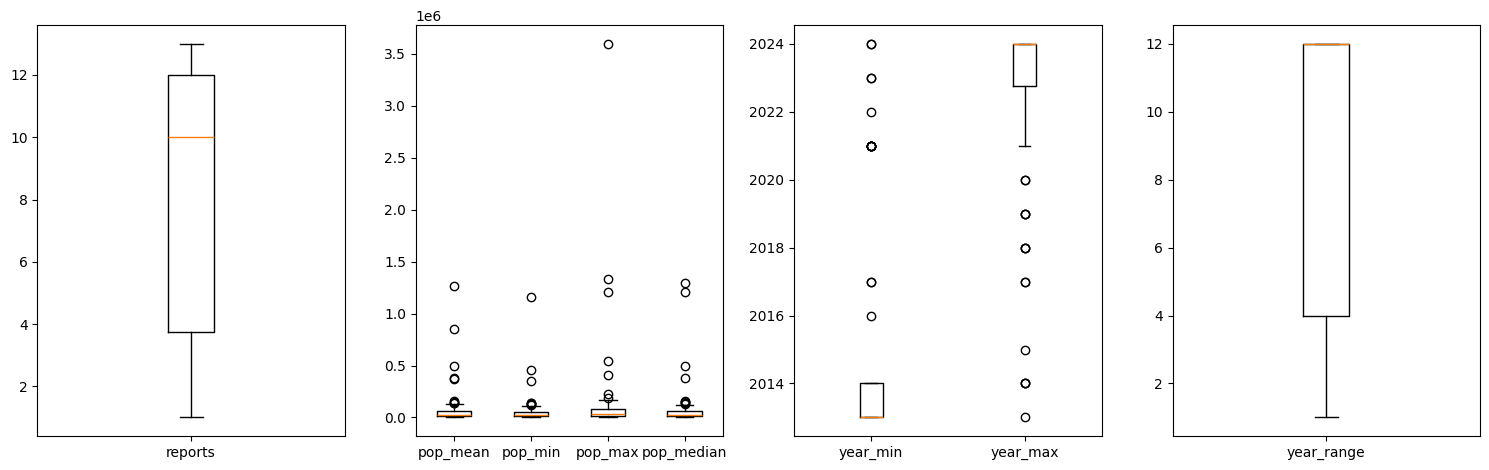

In [38]:
fig_box, ax_box = plt.subplots(1,4)
fig_box.set_figwidth(15)

ax_box[0].boxplot(providers['reports'],tick_labels=['reports'])
ax_box[1].boxplot(providers.loc[:,'pop_mean':'pop_median'],tick_labels=providers.loc[:,'pop_mean':'pop_median'].columns)
ax_box[2].boxplot(providers.loc[:,'year_min':'year_max'],tick_labels=providers.loc[:,'year_min':'year_max'].columns)
ax_box[3].boxplot(providers['year_range'],tick_labels=['year_range'])

fig_box.tight_layout()

In [39]:
providers.sort_values(['reports','year_range','pop_mean'],ascending=False).head(int(providers.shape[0]/2))

,,reports,pop_mean,pop_min,pop_max,pop_median,year_min,year_max,year_range,geometry
account_id,name,,,,,,,,,
longmont_city,Longmont,13,99580,93000,108865,99206,2013,2024,12,POINT (-11700281.883 4890578.05)
parker_dist,Parker Water & Sanitation District,13,57250,43764,73376,58433,2013,2024,12,POINT (-11666646.729 4793309.039)
evans_city,Evans,13,21619,20065,23120,21554,2013,2024,12,POINT (-11659807.977 4918994.465)
denver_water,Denver,12,1267333,1161000,1332000,1291000,2013,2024,12,POINT (-11674794.101 4831258.965)
co_springs_util,Colorado Springs,12,498700,458716,540698,496361,2013,2024,12,POINT (-11661151.636 4702739.802)
aurora_city,Aurora,12,378178,351200,405919,379972,2013,2024,12,POINT (-11657624.819 4824053.119)
loveland_city,Loveland,12,372184,71985,3595588,77495,2013,2024,12,POINT (-11695302.761 4926219.826)
thorton_city,Thornton,12,161748,139473,226525,158978,2013,2024,12,POINT (-11682384.767 4856367.086)
boulder_city,Boulder,12,153052,143621,159378,153000,2013,2024,12,POINT (-11716536.008 4869918.704)


### GPCD

In [40]:
metered['residential']['all'].__class__

# can probably use this to turn the below code into a for loop with gpcd = {} so we can have it for all categories?... do we need?
    # class = dict -> go another for loop then assign within that
    # class =/= dict -> assign value

pandas.core.frame.DataFrame

resample good for quick convserion from months to days
- creates intervening days if missing (i.e. Feb & Apr given, still fills through March)
  - but **ffill** fills through those added days, so would incorrectly add data for months that were not included originally
  - WORKAROUND: **resample('MS').asfreq()** to insert NaN where months are missing, then **resample('D').ffill()** to upsample to daily and fill values (excludes any pre-existing NaN values, which we inserted with the first resample)
- stops at the end, so need to add the following month to upsample the entire final month (i.e. add 01/01/2025 so that Dec 2024 expands to the month)

> make gcpd function to handle not only the combined residential?

In [41]:
def fxn_gpcd(account_id,pop_type='both',cols_return='GPCD'):
    '''
    area = account_id
    
    for residential combined use only

    population: 'permanent','transient','both','total'

    cols_return: 'GPCD','all'
    '''
    if pop_type == 'permanent':
        pop_col = ['Permanent Residential Population']
    elif pop_type == 'transient':
        pop_col = ['Transient Population']
    elif pop_type == 'both':
        pop_col = ['Total Population','Permanent Residential Population','Transient Population']
    elif pop_type == 'total':
        pop_col = ['Total Population']
    else:
        raise('An incompatible population type was specified. Choose from the following: ''permanent'',''transient'',''both'',''total''')
    
    #_ add population to calculate gallons per capita _#
    df = metered['residential']['combined'].loc[(account_id,slice(None),'Potable Treated')].join(population['yearly'])
        # NOTE: only using Potable Treated water type to avoid duplicate index values issue later
            # .loc[account_id]

    #_ calculate designated gallons per capita usage _#
    gpcd = df[['Metered Use (gallons)']+pop_col].reset_index(['DNR 1051 Report Name',
                                                    #   'Water Type', # see note above
                                                      'account_id',
                                                      'Report Year'],drop=True).sort_index()
    gpcd['Gallons per Capita'] = gpcd['Metered Use (gallons)'] / gpcd[pop_col[0]]

    #_ calculate daily avg in a new column _#
    gpcd['Gallons per Day'] = gpcd['Metered Use (gallons)'] / pd.Series(data=gpcd.index, index=gpcd.index).dt.days_in_month
    gpcd['GPCD'] = gpcd['Gallons per Capita'] / pd.Series(data=gpcd.index, index=gpcd.index).dt.days_in_month

    #_ fill in missing data with NaN to show gaps in the graphs _#
    gpcd = gpcd.resample('MS').asfreq()

    #-X don't need the in-depth resampling, good to just have the GPCD at the monthly level X-#
        #_ add the next month to the list in order for the resampling to extend the entire final month _#
            # gpcd = pd.concat([gpcd, pd.DataFrame(index=[gpcd.index.max() + pd.DateOffset(months=1)])])

        #_ resample (upsampling) to convert months to days -- ffill for use in calculating the daily average _#
            # gpcd = gpcd.resample('MS').asfreq().resample('D').ffill()

        #_ drop final row placeholder _#
            # gpcd = gpcd[:len(gpcd)-1]

    if cols_return == 'all':
        return gpcd
    else:
        return gpcd[[cols_return]+pop_col]

## Rate data

### CPI Adjustment

CPI typically considered as an annual metric, therefore will use annual CPI values rather than monthly or partial-year.

State of Colorado uses the **Denver-Aurora-Lakewood** CPI for budgeting ([link](https://dlg.colorado.gov/inflation-denver-aurora-lakewood-consumer-price-index)) so we will match that.

Using the imported CPIs, will convert all rates into their 2025-equivalent to normalize the cost for inflation using the following equation:

    Price_1 = Price_0 * (CPI_1 / CPI_0)

In [42]:
#__ import CPI data from BLS __#

data_CPI = fxn_CPI_load(filename='CPI_Denver-Aurora-Lakewood_BLS_20260114.xlsx')
data_CPI.head()

,CPI
Date,
1964-01-01,28.3
1965-01-01,28.8
1966-01-01,29.7
1967-01-01,30.0
1968-01-01,30.7


### Unit Tracking

Tracking units for both the variable rate data ($/unit) and the provided household-level use.

Assumed default of **kgal** for both

Will manually set values as needed if not kgal

Assuming that the reporting units for a given provider do NOT change over time. *If this turns out to be wrong, will need to incorporate units as a function of time in the data itself.*

In [43]:
account_units = pd.DataFrame(data='kgal',index=providers.index.get_level_values(0),columns=['rates_units','acct_data_units'])

#_ foco_city provided household usage in gallons _#
account_units.loc['foco_city','acct_data_units'] = 'gal'
account_units.loc['boulder_city','acct_data_units'] = 'gal'

### Categories Tracking

In [44]:
# a reminder of the list of categories used in the 1051HB data
pd.DataFrame(list_categories_1051HB)

,Customer Category
1,Commercial / Industrial
2,Irrigation
5,"Residential, Multi Family"
6,"Residential, Single Family"
11,Utility/Municipal
14,Bulk/Wholesale
26,SF and MF Residential Combined
235,Other
1674,Mixed Use


In [45]:
# import new reference list of categories for use with household data
ref_categories = fxn_excel_import(file_name='utility-data/Rates Research.xlsx', inc_sheets='end', index_col=[0,1])
ref_categories

name  \
group                   code                                                    
Agriculture             irrigation                                 Irrigation   
All                     all                                     All Customers   
Commercial / Industrial commercial                                 Commercial   
                        commercial-industrial         Commercial / Industrial   
                        industrial                                 Industrial   
Other                   bulk                                   Bulk/Wholesale   
                        mixed                                       Mixed Use   
                        non-res                           All Non-Residential   
                        other                                           Other   
Residential             res-MF                      Residential, Multi Family   
                        res-MF-small                    Residential, Small MF   
                        res-SF                     Residential, Single Family   
                        res-combined           SF and MF Residential Combined   
                        res-duplex                        Residential, Duplex   
                        res-no-budget            Non-Water-Budget Residential   
Utility/Municipal       utility-municipal                   Utility/Municipal   

                                                                                           notes  
group                   code                                                                      
Agriculture             irrigation                                                           NaN  
All                     all                                                                  NaN  
Commercial / Industrial commercial                                                           NaN  
                        commercial-industrial                                                NaN  
                        industrial                                                           NaN  
Other                   bulk                                                                 NaN  
                        mixed                                                                NaN  
                        non-res                                                              NaN  
                        other                                                                NaN  
Residential             res-MF                                                      as in 1051HB  
                        res-MF-small                                                         NaN  
                        res-SF                 as in 1051HB, might include subcategories as a...  
                        res-combined                                                         NaN  
                        res-duplex                               grouped with res-SF (foco_city)  
                        res-no-budget                                                        NaN  
Utility/Municipal       utility-municipal                                                    NaN

### Utility Rates

In [46]:
print(f'2025 CPI: {data_CPI.loc['01-01-2025'].values}')

2025 CPI: [335.07]


In [47]:
#_ importing the collected rates data for all providers _#

data_rates = fxn_excel_import(file_name='utility-data/Rates Research.xlsx', inc_sheets=-3, og_sheet_names=True, 
                              index_col=[0,1,2], skiprows=1, usecols='A:M',
                              names=['Category','Date','start'] + [i + j for j in ['1','2','3','4','5'] for i in ['cap_','rate_']])

for i in data_rates.keys():

    #_ calculate rates adjusted for inflation _#
    data_rates[i] = data_rates[i].join(data_CPI)
    data_rates[i]['CPI'] = data_rates[i]['CPI'].ffill()

    for col in [i + j for j in ['1','2','3','4','5'] for i in ['rate_']]:
        data_rates[i][f'adj_{col}'] = data_rates[i].apply(lambda x: inflation_adjuster(x[col],
                                                                              x['CPI'],
                                                                              data_CPI.loc['01-01-2025']),
                                                 axis = 1)
    data_rates[i].drop(columns='CPI', inplace=True)
    data_rates[i].sort_index(axis=1,inplace=True)

    #_ create multiindex for columns, sort so rates and caps are split (prep for graphing) _#
    data_rates[i].columns = pd.MultiIndex.from_product([['Rate per Unit (adjusted)','Tier Cap','Rate per Unit'],[i + j for j in ['1','2','3','4','5'] for i in ['Tier ']]])
        # REMOVE: data_rates[i] = data_rates[i].reorder_levels([1,0],axis=1).sort_index(axis=1)

    data_rates[i] = data_rates[i].reset_index('start')
    data_rates[i][('Tier Cap','Tier 0')] = data_rates[i]['start']
    data_rates[i].drop(columns=[('start','')],inplace=True)
    data_rates[i].sort_index(axis=1,inplace=True)

    # #_ calculate difference between tiers for graphing _#
    if i not in ['boulder_city','denver_water']: # TODO: boulder & denver have complex tier calculations that need to be processed (wait until get household use first)
        for n in list(range(data_rates[i]['Tier Cap'].columns.size-1,0,-1)):
            data_rates[i][('Tier Cap Diff',f'Tier {n}')] = data_rates[i]['Tier Cap'].apply(lambda x: np.nan if isinstance(x.iloc[0],str) else x.iloc[n]-x.iloc[n-1], axis=1)
            # .iloc[:,n] - data_rates[i]['Tier Cap'].iloc[:,n-1]
        data_rates[i][('Tier Cap Diff','Tier 0')] = data_rates[i]['Tier Cap'].iloc[:,0]# - data_rates[i]['start']
        # data_rates[i][('Tier Cap Diff','Tier 0')] = data_rates[i]['start']
        data_rates[i].sort_index(axis=1,inplace=True)

In [48]:
def plt_rates(provider,category,adjusted=False,ax=None,**kwargs):
    '''
    for creating individual historical rate plots
    can be used by itself or as an axis in an existing figure
    '''

    fig, ax = fxn_check_for_plots(ax=ax)

    axTiers = ax

    if adjusted == True:
        rates_type = ' (adjusted)'
    else:
        rates_type = ''

    rates_units = account_units.loc[provider,'rates_units']

    # figRates, axTiers = plt.subplots(figsize=(9,5))

    the_colors = {'area':['grey','powderblue','xkcd:light grey green','navajowhite','lightpink','thistle'],
                'lines':['steelblue','xkcd:army green','sienna','maroon','purple']} # using CSS Colors list unless marked as xkcd
        # yellow: area-'lemonchiffon' & lines-'goldenrod'

    axTiers.stackplot(data_rates[provider].loc[category].index,
                    data_rates[provider].loc[category]['Tier Cap Diff'].T,
                    colors=the_colors['area']
                    )
    axTiers.set_ylim((0,None))
    axTiers.set_ylabel(f'Tier Size ({rates_units})')

    axRates = axTiers.twinx()

    for i in list(range(5)):
        axRates.plot(data_rates[provider].loc[category][f'Rate per Unit{rates_type}'].iloc[:,i], # ' (adjusted)'
                    color=the_colors['lines'][i])
    axRates.set_ylim((None,None))
    axRates.set_ylabel(f'Rate ($/{rates_units})')

    for i in list(range(5)):
        if data_rates[provider].loc[category]['Tier Cap Diff'][f'Tier {i+1}'].isna().all():
            top_area = i+1
            break
        else:
            continue
    else:
        top_area = np.nan

    axTiers.set_facecolor(the_colors['area'][top_area])

    # plt.autoscale(enable=True, axis='x', tight=True)
    axTiers.set_xlim(data_rates[provider].loc[category].index.min(),data_rates[provider].loc[category].index.max())
    # axTest2.legend()
    axTiers.set_title(f'{providers.reset_index('name')['name'].loc[provider]} ({category})')

    axTiers.grid(True,axis='x')

In [49]:
def plt_rates_all_categories(provider, **kwargs):
    '''
    combines individual rate plots into 1 graph for all categories of a given provider
    ONLY for individual plot use (not for use in existing figures)
    '''
    fig_rates, ax_rates = plt.subplots(nrows=data_rates[provider].index.get_level_values(0).unique().to_list().__len__(), ncols=2)
    fig_rates.set_figwidth(15) # default: 6.4
    fig_rates.set_figheight(4.8 * fig_rates.get_axes().__len__()/2 * 0.75)

    i = 0
    for category in data_rates[provider].index.get_level_values(0).unique().to_list():
        plt_rates(provider,category,ax=ax_rates[i,0])
        plt_rates(provider,category,adjusted=True,ax=ax_rates[i,1])
        ax_rates[i,1].set_title(f'{ax_rates[i,1].get_title()} -- adjusted to 2025 CPI')
        for j in [0,1]:
            hlpr_center_xtick_labels(ax=ax_rates[i,j],rotation=30)
        i += 1
    fig_rates.tight_layout()

## 🐯 Household data

In [50]:
account_units.loc['foco_city']

rates_units        kgal
acct_data_units     gal
Name: foco_city, dtype: object

In [51]:
#_ define data groups -- must match exactly in csv filenames _#
data_household_groups = ['structures','accounts','account_units','usage','population']

#_ load in existing csv data files for each provider (using account_id) & each group _#
data_household = dict.fromkeys(providers.index.get_level_values(0).to_list())
for provider in data_household: # set groups for each provider
    data_household[provider] = dict.fromkeys(data_household_groups)
for provider in data_household.keys(): # load data into each group for each provider
    try:
        for group in data_household_groups:
            try: # import csv for each group if exists
                data_household[provider][group] = pd.read_csv(f'utility-data/z_household_imports/{provider}_{group}.csv')
                if 'id' in data_household[provider][group].columns: # set id as index when available
                    data_household[provider][group] = data_household[provider][group].set_index('id').sort_index()
                if group == 'usage': # convert monthly data column headers to datetime datatype
                    data_household[provider][group].columns = pd.to_datetime(data_household[provider][group].columns)
                else:
                    try: # if years are used for the column headers, convert column name datatype to int32
                        data_household[provider][group].columns = data_household[provider][group].columns.astype('int32')
                    except:
                        pass
            except: # if file not found for group, check for split files (e.g., by year) and make df from all found
                continue                
    except:
        continue
    finally: # check for yearly template files for the provider
        try:
            files = []
            #_ get list of files that match search _#
            for file in glob.glob(f'utility-data/z_household_imports/{provider}_template_[0-9]*.csv'):
                files += [file]
            #_ read each file into a df & concat them all together (parsing date column at same time) _#
            template_df = pd.concat((pd.read_csv(x,
                                                 dtype={'id':int,'usage':float,'category':str,'notes':str},
                                                 parse_dates=[1],
                                                 date_format={'date':'%Y-%m-%d'}) for x in files),
                                    ignore_index=True)
            #_ drop duplicates id & date entries (keep largest 'usage' value) | fxn also sets & sorts index _#
            template_df = fxn_df_duplicates(template_df,columns=['id','date'],type='drop',sort_col=['usage'])
            #_ aggregate by month (sum only usage), set to month start, to simplify data
            template_df = template_df.groupby([pd.Grouper(level='id'),
                                    pd.Grouper(level='date',freq='MS')]
                                    ).agg({'usage':'sum','category':'first','notes':'first'}) # ,'Residential Customer Category':'first'
            data_household[provider]['usage'] = template_df['usage'].unstack()
            data_household[provider]['accounts'] = template_df['category'].unstack()
            # NOTE not currently creating df for 'notes'
            
            del files, template_df
        except:
            continue
        finally:
            cleaned_dict = {}
            for key, value in data_household[provider].items():
                if type(value) is pd.DataFrame:
                    if not value.empty:
                        cleaned_dict[key] = value
                elif value is not None:
                    cleaned_dict[key] = value
            data_household[provider] = cleaned_dict

In [52]:
data_household['westminster_city']['accounts'].head()

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
id,,,,,,,,,,
1,E,E,E,E,E,E,E,E,E,E
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,O,O
3,E,E,E,E,E,E,E,E,E,E
4,E,E,E,E,E,E,E,E,E,E
5,E,E,E,E,E,E,E,E,E,E


In [53]:
def fxn_usage_filter(provider,group=[],category=[],time_endcaps_only=False,dropna='all',**kwargs):
    '''
    dropna: 'all','any',False
    '''
    categories_df = ref_categories.reset_index()
    categories_df = categories_df.loc[(categories_df['group'].isin(group)) + \
                                      (categories_df['code'].isin(category)),
                                      :]
    
    usage_df = data_household[provider]['usage']
    accounts_df = data_household[provider]['accounts']
    structures_df = data_household[provider]['structures'] if 'structures' in data_household[provider].keys() else None
    acct_units_df = data_household[provider]['account_units'] if 'account_units' in data_household[provider].keys() else None
    
    #_ get codes as used by the provider as defined by the filter _#
    try:
        code_filter = structures_df[structures_df['group_code'].isin(categories_df['code'])]['structure_code'].to_list()
    except:
        code_filter = categories_df['code'].to_list()

    #_ filter account id's that have no match for any of the strucutre codes _#
    accounts_df = accounts_df[accounts_df.isin(code_filter)].dropna(how='all').index

    #_ select only the usage & units data for account id's included in the above list _#
    usage_df = usage_df.loc[accounts_df]
    if type(acct_units_df) is pd.DataFrame:
        acct_units_df = acct_units_df.loc[accounts_df]

    #_ filter columns based on chosen time parameters _#
        # year_start,   year_end,   month   --> 1 entry for each selected year for chosen month
        # month_start,  month_end,  year    --> 1 entry for each selected month for chosen year
        # year_start,   year_end            --> monthly data for duration
        # if none specified, will return all columns

    def time_range(start,end):
        return [start,end] if time_endcaps_only else list(range(start,end+1))

    try:
        time_start,time_end = [kwargs[key] for key in ['year_start','year_end']]
        try:
            [time_select] = [kwargs[key] for key in ['month']]
            usage_df = usage_df.sort_index(axis=1,key=lambda col: col.month + (col.year * 0.0001))
        except:
            time_select = []
        finally:
            usage_df = usage_df.loc[:,usage_df.columns.year.isin(time_range(time_start,time_end))]
            usage_df = usage_df.loc[:,usage_df.columns.month==time_select] if time_select else usage_df
            if type(acct_units_df) is pd.DataFrame:
                acct_units_df = acct_units_df.loc[:,acct_units_df.columns.isin(time_range(time_start,time_end))]
    except:
        try:
            time_select,time_start,time_end = [kwargs[key] for key in ['year','month_start','month_end']]
            usage_df = usage_df.loc[:,(usage_df.columns.month.isin(time_range(time_start,time_end))) & (usage_df.columns.year==time_select)]
        except:
            pass

    if dropna in ['any','all']:
        # 'all' removes excess rows that have no data in them (particularly useful for time filters, but should match shape of "False" when no time filters used)
        # 'any' removes rows that have NaN in any cell -- can be useful if finding issues with calculating differences
        usage_df = usage_df.dropna(how=dropna)
        if type(acct_units_df) is pd.DataFrame:
            acct_units_df = acct_units_df.dropna(how=dropna)

    if type(acct_units_df) is pd.DataFrame:
        return usage_df, acct_units_df
    else:
        return usage_df

In [54]:
### FORT COLLINS RECORDS PROCESSING NOTES ###

# (4639425, 3) -- all records
# (4636682, 1) -- after dropping duplicates (id's & dates) -- also set indices
# (4560840, 1) -- after aggregating (sum) over each month => not sure if we *want* to do this though? makes it easier for widening the table though...
# (92604, 143) -- after unstacking: household id's in rows, months in columns (1/2014 through 11/2025)

In [55]:
# 🐯 add pre-calc descriptions & info

In [56]:
# df['account_usage'] = {}
# for id in df['usage'].index:
#     df['account_usage'][id] = pd.DataFrame(df['usage'].loc[id].T).sort_index().rename(columns={id:'usage'})

In [57]:
# df['account_usage'][sel_id]['year'] = df['account_usage'][sel_id].index.year
# df['account_usage'][sel_id].join(df['accounts'].loc[sel_id].T,on=['year']).rename(columns={sel_id:'structure_code'})\
#     .join(df['account_units'].loc[sel_id].T,on=['year']).rename(columns={sel_id:'units'}).drop(columns='year').head()

# Analysis

## Define key variables

In [152]:
sel_provider = 'westminster_city' # 'foco_city'
sel_category = 'res-SF'

## Rates Plot

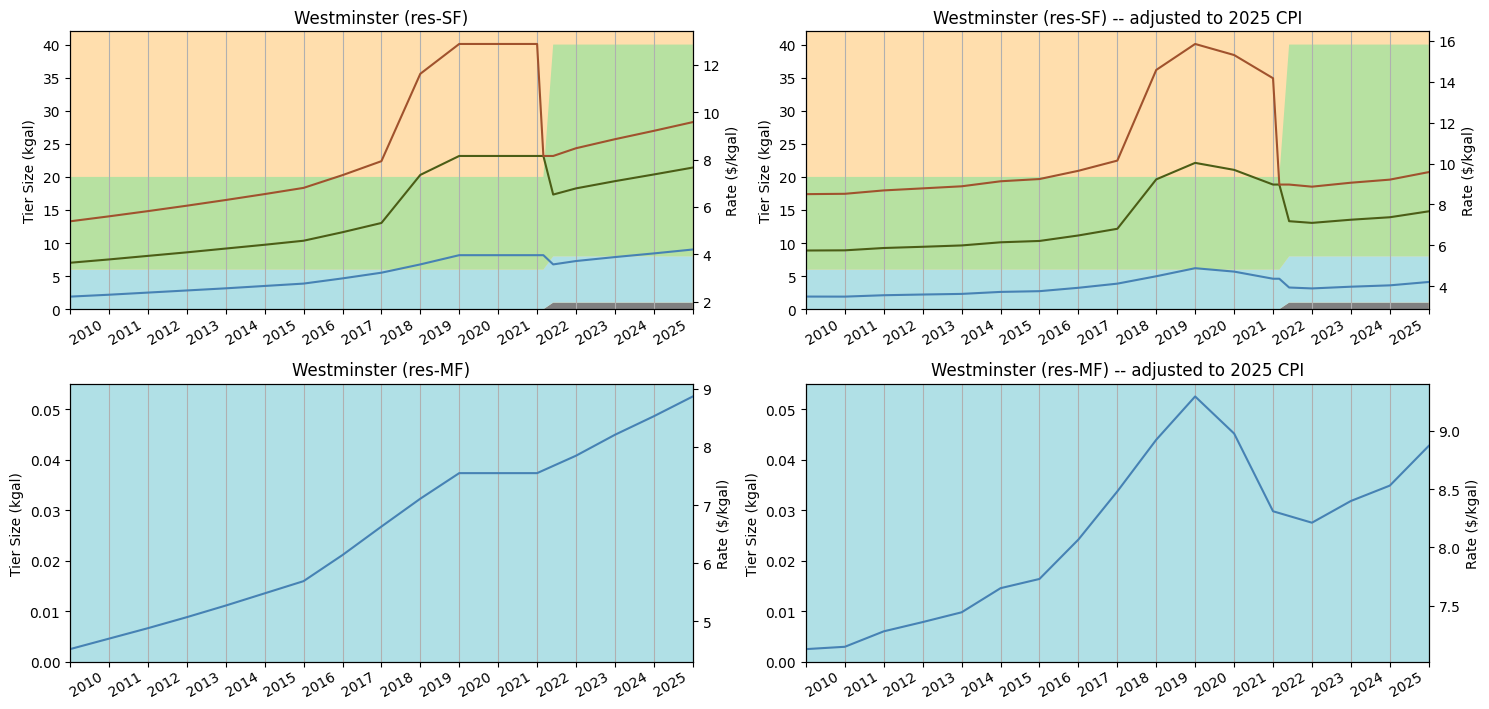

In [153]:
plt_rates_all_categories(sel_provider)
# data_rates[sel_provider].head()

## GPCD Plot

includes:
  - rate trends
  - gpcd metered usage
  - population
    - if a given population = 0 for all reports, will only show the other
    - select "total" or "both":
      - calculate usage based on total population
      - show either both non-zero populations or just a total population graph
    - select "permanent" or "transient":
      - calculate usage based only on the selected type
        - *do we need this? or should it just always calculate based on total?*
      - show only the selected pop type

linked closely to **fxn_gpcd**

💭 making a loop through all (or a selection) of the cities & exporting/ saving each as an image to look at (rather than manually looking through multiple)

🧋 [ Sam Stein ] `We noticed that some accounts are reporting either very low or zero metered used for a given report. For Aurora's 2023 report, it looks like there is a discrepancy in the reported metered use and the reporting units (the volume matches closer to the 2022 report using Gallons Thousands, but it is labelled as being reported in Gallons). Boulder reported 0 acre-feet for its 2018-2020 residential usage -- and it looks like the 2018 report was entirely a zero-volume report for all categories. Similar data gaps exist with some population reports, such as with Parker Water and Sanitation District, which reported 0 population for 2017 and 2022. Do you have any advice on how to proceed with interpreting reporting oddities like these?`

In [60]:
def plt_GPCD_population(account_id,pop_type='both',show_both_pop=False,ax=None,**kwargs):
    
    fig, ax = fxn_check_for_plots(ax)

    ax_GPCD_pop = ax

    df = fxn_gpcd(account_id=account_id,pop_type=pop_type)
    xaxis = pd.DataFrame({'date':fxn_gpcd(account_id=account_id).index.to_series()})
    xaxis['year'] = xaxis

    pop_data = df.iloc[:,1 if pop_type!='both' else range(2,4) if show_both_pop==True else 2 if df.iloc[:,3].sum()==0 else 3 if df.iloc[:,2].sum()==0 else range(2,4)]

    ax_GPCD_pop.set_title('Reported Population')
    ax_GPCD_pop.plot(pop_data)
    #   option 2: # ax_GPCD_pop.stackplot(pop_data.index,pop_data.iloc[:,0],pop_data.iloc[:,1])
    ax_GPCD_pop.set_ylabel('Reported Population')
    hlpr_center_xtick_labels(ax=ax_GPCD_pop,rotation=30)

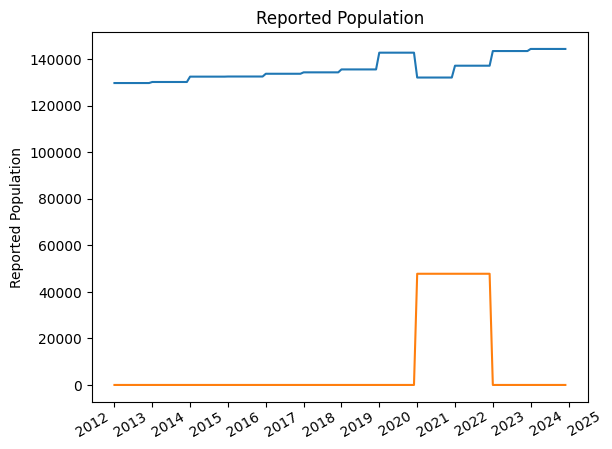

In [61]:
plt_GPCD_population(sel_provider)

In [62]:
def plt_GPCD(account_id,pop_type='both',ax=None,**kwargs):
    
    fig, ax = fxn_check_for_plots(ax)

    ax_GPCD_usage = ax

    df = fxn_gpcd(account_id=account_id,pop_type=pop_type)
    xaxis = pd.DataFrame({'date':fxn_gpcd(account_id=account_id).index.to_series()})
    xaxis['year'] = xaxis

    usage_data = df['GPCD']

    ax_GPCD_usage.set_title('Residential Per Capita Usage')
    ax_GPCD_usage.plot(usage_data)
    ax_GPCD_usage.set_ylabel('Metered Usage per Capita (gallons)')
    hlpr_center_xtick_labels(ax=ax_GPCD_usage,rotation=30)

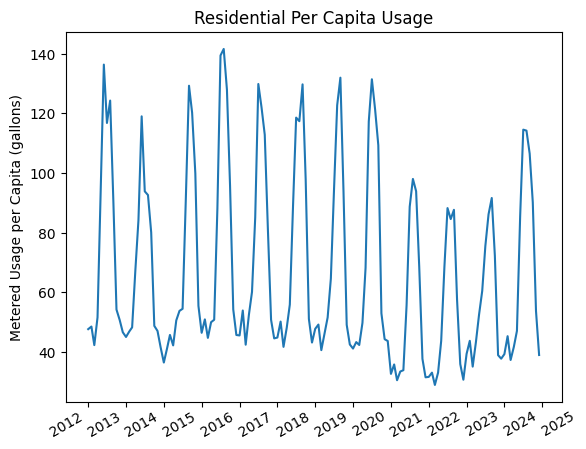

In [63]:
plt_GPCD(sel_provider)

In [64]:
def plt_GPCD_combined_fig(account_id,pop_type='both',show_both_pop=False, category='Residential, Single Family', df_return=all):
    '''
    df_return: 'all','head','none'
    '''
    df = fxn_gpcd(account_id=account_id,pop_type=pop_type)
    xaxis = pd.DataFrame({'date':fxn_gpcd(account_id=account_id).index.to_series()})
    xlim = (xaxis.index.min(),xaxis.index.max())

    title = providers.reset_index('name')['name'].loc[account_id]
    
    fig_GPCD = plt.figure(figsize=[14, 7])
    fig_GPCD.suptitle(title)

    if account_id in data_rates.keys() and category in data_rates[account_id].index:
        grid_shape = (5,2)
        i = 0

        ax_GPCD_rates = plt.subplot2grid(grid_shape,(0,0),rowspan=2)
        plt_rates(provider=account_id,category=category,ax=ax_GPCD_rates)
        ax_GPCD_rates.set_title(f'Rates Implemented ({category})')

        # ax_GPCD_rates_adj = plt.subplot2grid(grid_shape,(0,1),rowspan=1)
        # plt_rates(provider=account_id,category=category,adjusted=True,ax=ax_GPCD_rates_adj)
    else:
        grid_shape = (1,2)
        i = 2
        fig_GPCD.set_figheight(4)
    
    ax_GPCD_usage = plt.subplot2grid(grid_shape,(2-i,0),rowspan=3-i)
    plt_GPCD(account_id=account_id,pop_type=pop_type,ax=ax_GPCD_usage)

    ax_GPCD_pop = plt.subplot2grid(grid_shape,(2-i,1),rowspan=3-i)
    plt_GPCD_population(account_id=account_id,pop_type=pop_type,show_both_pop=show_both_pop,ax=ax_GPCD_pop)

    for ax in fig_GPCD.get_axes():
        ax.set_xlim(xlim)
        hlpr_center_xtick_labels(ax=ax,rotation=30)

    fig_GPCD.tight_layout()

    plt.savefig(f'1051graphs/{account_id}_GPCD.png')
    plt.show()

    if df_return == 'all':
        return df
    elif df_return == 'head':
        return df.head()
    
    #-X old rates code, keeping for reference formatting if needed X-#
        # ax_GPCD_rates.set_title('Rates Implemented')
        # ax_GPCD_rates.stackplot(data_rates['Westminster, City of'].index,
        #                         data_rates['Westminster, City of']['Gal Cap']['Tier 1'],
        #                         data_rates['Westminster, City of']['Gal Cap']['Tier 2 ']-data_rates['Westminster, City of']['Gal Cap']['Tier 1'],
        #                         colors=['black','grey'])
        # ax_GPCD_rates.set_ylabel('Tier Size (gallons)')
        # ax_GPCD_rates.xaxis.set_major_locator(mdates.YearLocator())
        # ax_GPCD_rates.tick_params(axis='x', rotation=30)
        # ax_GPCD_rates2 = ax_GPCD_rates.twinx()
        # ax_GPCD_rates2.plot(data_rates['Westminster, City of']['Rate (USD $)'])
        # ax_GPCD_rates2.set_ylabel('Rate ($/gal)')

    # axTest2.legend()

> check population gaps (see Parker)

> also check gaps in usage (see Boulder)

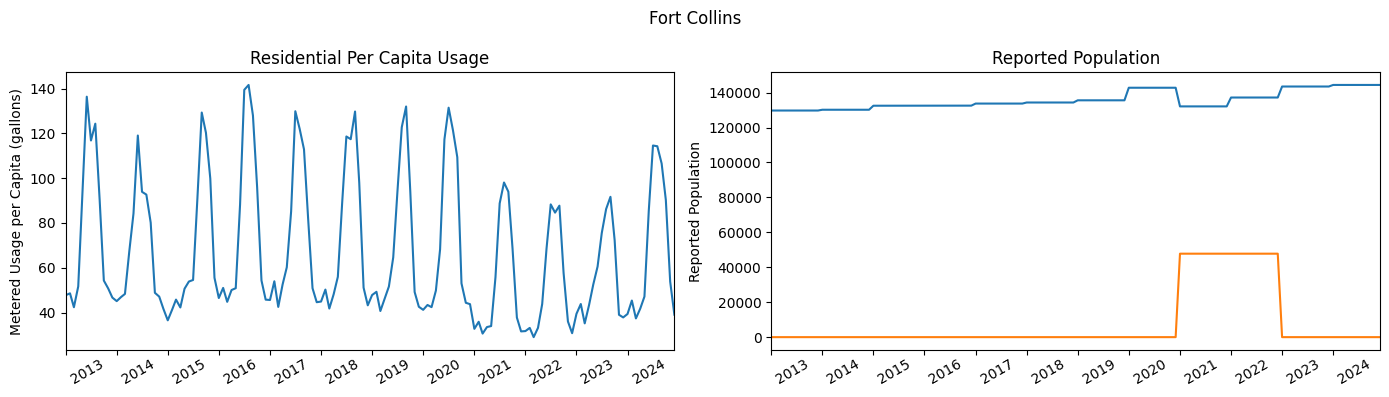

,GPCD,Total Population,Permanent Residential Population,Transient Population
date,,,,
2013-01-01,47.709248,129751,129751,0
2013-02-01,48.582064,129751,129751,0
2013-03-01,42.364022,129751,129751,0
2013-04-01,51.663057,129751,129751,0
2013-05-01,93.280405,129751,129751,0


In [65]:
plt_GPCD_combined_fig(sel_provider,pop_type='both',df_return='head')#,show_both_pop=True)
# longmont          ->  ,category='Residential'
# greeley, pueblo   ->  ,category='Single Family Residential'

## 🐯 Bill Costs

Block structure bill calculations:
$$
    [p_1 * (w_1 - w_0)] + [p_2 * (w_2 - w_1)] + ... + [p_n * (w - w_{n-1})]
$$
$$
    = \sum 
    \begin{cases}
        p_n * (w_n - w_{n-1}),& \text{if } w\geq w_n\\
        p_n * (w - w_{n-1}),&   \text{if } w\lt w_n
    \end{cases}
$$

In [88]:
def fxn_calc_bill(provider,category,head=False,**kwargs):
    '''
    **kwargs to pass into fxn_usage_filter
    '''
    # account for # of units in a given account
    
    df_t = data_rates[provider].loc[category,'Tier Cap']
    df_r = data_rates[provider].loc[category,'Rate per Unit']
    
    filter = fxn_usage_filter(provider,category=[category],**kwargs)
    if type(filter) is tuple:
        df_u, df_n = filter
    elif type(filter) is pd.DataFrame:
        df_u = filter
        df_n = None
        
    if head:
        df_u = df_u.head(head)

    units_check = account_units.loc[provider].to_list()
    if units_check[0] is not units_check[1]:
        df_u = df_u.pipe(fxn_convert_to_gallons,units=units_check[1],target_unit=units_check[0])

    df_ref = {'u':df_u,'n':df_n,'t':df_t,'r':df_r}

    df_bills = pd.DataFrame(index=df_u.index,columns=df_u.columns)
    for row in df_u.index:
        for col in df_u.columns:
            x = df_u.loc[row,col]
            try:
                get_acct_units = df_n.loc[row,col.year]
            except:
                get_acct_units = 1
            get_rates = df_r.iloc[df_r.index.get_indexer([col],method='pad')]
            get_tiers = df_t.iloc[df_t.index.get_indexer([col],method='pad')] * get_acct_units
            get_tier_sizes = get_tiers.where(get_tiers<=x).fillna(value=x,axis=1,limit=1).diff(axis=1) 
            get_tier_costs = get_rates * get_tier_sizes
            get_bill = get_tier_costs.agg('sum',axis=1)
            df_bills.loc[row,col] = get_bill.iloc[0]
    
    df_bills = df_bills.astype(np.float64)

    # df_check = {'get_rates':get_rates,'get_tiers':get_tiers,'get_tier_sizes':get_tier_sizes,'get_tier_costs':get_tier_costs}

    return df_bills, df_ref#, df_check

    #_ trying to speed up the code... but I broke it lol so leaving it here for later _#

    # '''
    # **kwargs to pass into fxn_usage_filter
    # '''
    # # account for # of units in a given account
    # df_u, df_n = fxn_usage_filter(provider,category=[category],**kwargs)
    # df_t = data_rates[provider].loc[category,'Tier Cap']
    # df_r = data_rates[provider].loc[category,'Rate per Unit']

    # # print(df_u.shape)

    # # df_u, df_n = df_u.head(1000), df_n.head(1000)

    # df_bills = pd.DataFrame(index=df_u.index,columns=df_u.columns)
    # for col in df_u.columns:
    #     get_rates = df_r.iloc[df_r.index.get_indexer([col],method='pad')]
    #     get_tiers = df_t.iloc[df_t.index.get_indexer([col],method='pad')]
    #     get_acct_units = df_n.loc[:,col.year]
    #     # get_tiers = get_tiers.merge(get_acct_units.reset_index()['id'],how='cross').set_index('id').mul(get_acct_units,axis=0)
    #     for row in df_u.index:
    #         x = df_u.at[row,col]
    #         # get_acct_units = df_n.loc[row,col.year]
    #         get_tiers = get_tiers * get_acct_units.at[row]
    #         get_tier_sizes = get_tiers.where(get_tiers<=x).fillna(value=x,axis=1,limit=1).diff(axis=1) 
    #         get_tier_costs = get_rates * get_tier_sizes
    #         get_bill = get_tier_costs.sum(axis=1)
    #         df_bills.at[row,col] = get_bill.iat[0]
    
    # df_bills = df_bills.astype(np.float64)

    # df_ref = {'u':df_u,'n':df_n,'t':df_t,'r':df_r}

    # df_check = {'get_rates':get_rates,
    #             'get_tiers':get_tiers,
    #             'get_tier_sizes':get_tier_sizes,
    #             'get_tier_costs':get_tier_costs
    #             }

    # return df_bills, df_ref, df_check

In [89]:
#_ LONG-RUNNING CODE, RUN ONLY ONCE FOR A GIVEN SUBSET, SAVES TO CSV TO LOAD IN _#
# df_bills, df_ref = fxn_calc_bill(provider=prov,category=cat)
# df_bills.to_csv(f'utility-data/z_bills/{prov}_{cat}_bills.csv',chunksize=1000)
# with open(f'utility-data/z_bills/{prov}_{cat}_ref.pickle','wb') as pickle_file:
#     pickle.dump(df_ref, pickle_file)
    
###   T I M I N G   N O T E S   ###

# "at" replaced `loc` with `at` within the inner loop

# westminster, res-SF
    # loc, full timespan, to_csv() == 148 minutes to calculate bills
    # loc, 2018, June, head() == 1m 11.4s ... 13.9s
    #  at, 2018, June, head() == 1m 10.8s ... 13.4s
    #  ^^^^, removed astype() == 1m  5.9s --> except that "at" still results in dtype object, so still need to set the type...

In [90]:
# fxn_usage_filter(prov,category=[cat]).head().pipe(fxn_convert_to_gallons,units=account_units.loc['foco_city'].to_list()[1],target_unit=account_units.loc['foco_city'].to_list()[0])
# fxn_calc_bill(prov,category=cat,head=5)[0]

# filter_kwargs = {'time_endcaps_only':False,'year_start':2017,'year_end':2020,'month':6}
# filter_kwargs = {'time_endcaps_only':False,'year_start':2017,'year_end':2018, 'month':6}          # fxn...(..., **filter_kwargs)

# df_bills, df_ref, df_check = fxn_calc_bill(provider=prov,category=cat,**filter_kwargs)

# df_bills.head()

# NOTE --> separate function to define df_ref things outside of the df_bill? or overkill?

### get df

In [ ]:
#_ read external, pre-calculated bills df back into notebook _#
df_bills = pd.read_csv(f'utility-data/z_bills/{sel_provider}_{sel_category}_bills.csv',index_col=0)
df_bills.columns = pd.to_datetime(df_bills.columns)
with open(f'utility-data/z_bills/{sel_provider}_{sel_category}_ref.pickle','rb') as pickle_file:
    df_ref = pickle.load(pickle_file)

In [92]:
df_bills.describe()

,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
count,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.00000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.00000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.00000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000
mean,12.467728,11.060009,11.431913,15.333744,13.813673,21.801804,43.27010,58.178743,55.000496,31.147087,12.160414,11.934339,12.491813,11.293355,12.349003,12.592691,15.331946,43.468836,58.583810,62.918102,49.573202,29.588996,17.836385,12.031623,13.426095,11.019828,14.926364,16.808202,22.929389,41.246486,70.681739,49.44730,53.515108,22.042369,13.550600,11.996180,14.336923,13.631074,12.967362,15.56044,25.532557,66.989433,76.836601,60.426785,55.695063,29.839533,13.950468,13.275978,15.546807,14.558074,14.470667,16.089618,24.524703,43.847190,67.504793,83.003632,75.779329,42.846972,16.457320,15.003880,16.454173,17.242663,16.762308,20.481891,40.409758,78.972116,100.488819,104.483841,83.472581,54.585364,24.244036,17.287592,16.671926,15.459798,16.801462,17.999828,19.205554,40.334785,82.357961,97.327682,91.256430,63.308526,22.759853,18.868281,17.233722,16.777570,14.611012,20.612044,39.922966,44.782511,58.554611,55.594279,51.687788,33.310208,15.486233,10.643446,11.733606,11.097809,9.420799,12.098582,17.685157,23.100624,36.079564,52.927628,49.202502,32.885481,15.642582,10.684218,11.951258,11.441852,10.132365,12.

### tester

In [93]:
#_ BILL   FUNCTION   CHECKER _#

def tester_check_fxn_calc_bill(bills_df_to_check,**kwargs):
    #0 (optional) select id or date parts of interest

    # chk_id = 23917
    # chk_year = 2020
    # chk_month = 6

    #1 get dataframes & variables
    try:
        chk_usage_df, chk_acct_units_df = fxn_usage_filter(sel_provider,category=[sel_category])
    except:
        chk_usage_df = fxn_usage_filter(sel_provider,category=[sel_category])
        chk_acct_units_df = None
    chk_tiers_df = data_rates[sel_provider].loc[sel_category,'Tier Cap']
    chk_rates_df = data_rates[sel_provider].loc[sel_category,'Rate per Unit']

    chk_rand = bills_df_to_check.sample().dropna(axis=1).sample(axis=1)

    chk_rptd_units = account_units.loc[sel_provider].to_list()

    try:
        chk_id = kwargs['chk_id']
    except:
        chk_id = chk_rand.index[0]

    print(f'Account ID: {chk_id}')

    try:
        chk_year = kwargs['chk_year']
        chk_month = kwargs['chk_month']
    except:
        chk_date = chk_rand.columns[0]
    else:
        chk_date = pd.to_datetime(f'{chk_year}-{chk_month:0=2}-01')

    print(f'Selected Date: {chk_date:%Y-%m-%d}\n')

    #2 get values for given id and date
    chk_usage = chk_usage_df.loc[chk_id,chk_date]
    print(f'Metered Use: {chk_usage} {chk_rptd_units[1]}')

    try:
        chk_acct_units = chk_acct_units_df.loc[chk_id,chk_date.year]
    except:
        chk_acct_units = chk_acct_units_df
    print(f'# Units for Account: {chk_acct_units}\n')

    chk_rates = chk_rates_df.iloc[chk_rates_df.index.get_indexer([chk_date],method='pad')]
    print(f'Rates for {chk_date:%Y-%m-%d}:')
    display(chk_rates)

    chk_tiers = chk_tiers_df.iloc[chk_tiers_df.index.get_indexer([chk_date],method='pad')]
    print(f'\nBase Tier Caps for {chk_date:%Y-%m-%d}:')
    display(chk_tiers)

    #3 adjust tier caps for account units (westminster)
    chk_tiers_adj = chk_tiers * (chk_acct_units if chk_acct_units else 1)
    print(f'\nTier Caps adjusted for # of Units ({chk_acct_units}) in selected Account:')
    display(chk_tiers_adj)

    #4 convert usage to match rates units (i.e. kgal and $/kgal)
    if chk_rptd_units[0] is not chk_rptd_units[1]:
        chk_usage_conv = fxn_convert_to_gallons(chk_usage,units=chk_rptd_units[1],target_unit=chk_rptd_units[0])
        print(f'\nMetered amt: {chk_usage} {chk_rptd_units[1]}\nConverted to: {chk_usage_conv} {chk_rptd_units[0]}')
        chk_usage = chk_usage_conv

    #4 determined amount of actual use within each tier
    chk_use_tiers = chk_tiers_adj.where(chk_tiers_adj<=chk_usage).fillna(value=chk_usage,axis=1,limit=1).diff(axis=1)
    print(f'\nAmount of Actual Usage ({chk_usage} {chk_rptd_units[0]}) Spread Across each Tier:')
    display(chk_use_tiers)

    #5 calculate amount billed per tier
    chk_tier_bill_amts = chk_rates * chk_use_tiers
    print(f'Amount ($) billed for each tier of use:')
    display(chk_tier_bill_amts)

    #6 sum tier bills to get total bill

    chk_bill = chk_tier_bill_amts.sum(axis=1).iloc[0]
    print(f'Total Bill: ${chk_bill:,.2f}')

    #7 compare to fxn_calc_bill
    print(f'\nCalculated Bill: ${bills_df_to_check.loc[chk_id,chk_date]}')

In [94]:
data_household['boulder_city']['accounts'].head()

date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,2014-11-01,2014-12-01,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF
2,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF,res-SF
3,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-MF,res-

In [95]:
fxn_usage_filter('boulder_city',category=['res-SF']).head()

date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,2014-11-01,2014-12-01,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4000.0,6000.0,5000.0,3000.0,5000.0,6000.0,4000.0,2000.0,4000.0,4000.0,3000.0,5000.0,5000.0,3000.0,4000.0,0.0,5000.0,5000.0,2000.0,2000.0,3000.0,4000.0,4000.0,4000.0,5000.0,5000.0,4000.0,6000.0,5000.0,6000.0,5000.0,6000.0,6000.0,6000.0,4000.0,7000.0,3000.0,3000.0,3000.0,3000.0,3000.0,4000.0,4000.0,5000.0,5000.0,6000.0,4000.0,4000.0,1000.0,1000.0,2000.0,2000.0,1000.0,2000.0,3000.0,2000.0,2000.0,2000.0,1000.0,2000.0,2000.0,1000.0,2000.0,1000.0,1000.0,2000.0,2000.0,2000.0,1000.0,1000.0,1000.0,2000.0,2000.0,1000.0,1000.0,2000.0,2000.0,2000.0,1000.0,2000.0,2000.0,2000.0,2000.0,2000.0,1000.0,2000.0,1000.0,4000.0,0.0,0.0,2000.0,2000.0,2000.0,3000.0,2000.0,2000.0,2000.0,2000.0,2000.0,1000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,3000.0,2000.0,2000.0,1000.0,2000.0,10000.0,5000.0,1000.0,1000.0,3000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,1000.0,3000.0,2000.0,0.0,2000.0,1000.0,1000.0,0.0,1000.0,2000.0,1000.0,0.0,6000.0,9000.0,6000.0,7000.0,5000.0,4000.0
2,5000.0,4000.0,0.0,0.0,6000.0,0.0,24000.0,25000.0,17000.0,17000.0,10000.0,0.0,5000.0,5000.0,3000.0,0.0,1000.0,5000.0,14000.0,26000.0,0.0,23000.0,11000.0,4000.0,4000.0,2000.0,0.0,2000.0,3000.0,17000.0,24000.0,26000.0,25000.0,24000.0,21000.0,8000.0,3000.0,2000.0,3000.0,2000.0,3000.0,12000.0,23000.0,36000.0,0.0,17000.0,1000.0,6000.0,4000.0,3000.0,3000.0,4000.0,4000.0,7000.0,22000.0,21000.0,20000.0,19000.0,2000.0,3000.0,4000.0,3000.0,3000.0,2000.0,4000.0,6000.0,19000.0,21000.0,24000.0,14000.0,4000.0,2000.0,3000.0,4000.0,2000.0,3000.0,3000.0,18000.0,21000.0,20000.0,24000.0,17000.0,9000.0,4000.0,4000.0,3000.0,4000.0,2000.0,9000.0,5000.0,21000.0,23000.0,24000.0,23000.0,11000.0,2000.0,3000.0,3000.0,2000.0,3000.0,8000.0,14000.0,24000.0,32000.0,27000.0,25000.0,8000.0,2000.0,4000.0,2000.0,3000.0,2000.0,2000.0,2000.0,9000.0,21000.0,21000.0,15000.0,9000.0,3000.0,4000.0,3000.0,2000.0,2000.0,2000.0,13000.0,5000.0,47000.0,22000.0,17000.0,9000.0,3000.0,4000.0,2000.0,2000.0,3000.0,3000.0,3000.0,19000.0,25000.0,17000.0,13000.0,5000.0,2000.0
13,6000.0,9000.0,3000.0,5000.0,0.0,5000.0,0.0,9000.0,9000.0,5000.0,5000.0,6000.0,5000.0,4000.0,4000.0,4000.0,4000.0,5000.0,5000.0,10000.0,13000.0,10000.0,4000.0,4000.0,3000.0,5000.0,4000.0,4000.0,4000.0,3000.0,10000.0,8000.0,7000.0,

In [96]:
test_kwargs = {}#'time_endcaps_only':True,'year_start':2024,'year_end':2025,'month':4}
# test_bills_df = fxn_calc_bill(sel_provider,category=sel_category,head=5,**test_kwargs)[0]

In [97]:
tester_check_fxn_calc_bill(df_bills)#chk_id=21279,chk_year=2020,chk_month=6)

# potential IDs of interest:
    # 1253,5852,5987,7474,8118,8866,10034,10675,19735,23917,25116,26812,31450,32328 # --> had INC. water use with DEC. price per kgal from 2018 to 2020
        # NOTE: all of them had # units increase from 1 (2018) to 15 (2020) which adjusts the tier size

Account ID: 24623
Selected Date: 2018-05-01

Metered Use: 6.0 kgal
# Units for Account: 1.0

Rates for 2018-05-01:


,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5
Date,,,,,
2018-01-01,3.22,5.32,7.93,NaN,NaN



Base Tier Caps for 2018-05-01:


,Tier 0,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5
Date,,,,,,
2018-01-01,0,6.0,20.0,NaN,NaN,NaN



Tier Caps adjusted for # of Units (1.0) in selected Account:


...


Amount of Actual Usage (6.0 kgal) Spread Across each Tier:


,Tier 0,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5
Date,,,,,,
2018-01-01,NaN,6.0,0.0,NaN,NaN,NaN


Amount ($) billed for each tier of use:


,Tier 0,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5
Date,,,,,,
2018-01-01,NaN,19.32,0.0,NaN,NaN,NaN


Total Bill: $19.32

Calculated Bill: $19.32


**it looks like everything is calculating correctly**

_unexpected price decrease with usage increase might be due to the odd **increase in the account's units qty** in 2020_

however, graphing 2015 vs 2016 (still June) the graph looks quite similar...

> need to try to find examples of elasticity graphs to reference

## 🐯 Elasticity

- usage difference
- bill difference
- comparison

**Price Elasticity:** percentage change in water demand in response to a 1% change in price

Elasticity equation:

$$
    \varepsilon = \frac{\frac{\Delta w}{w}}{\frac{\Delta p}{p}} = \frac{\Delta w}{\Delta p} * \frac{p}{w}
$$

***$w$ demanded falls as $p$ rises, $\therefore$ $\varepsilon <0$ (demand slope, water (x) vs price (y) is negative)***

when demand is price **inelastic:** $-1<\varepsilon <0$
- 1% change in price induces a < %1 change in water use

when demand is price **elastic:** $\varepsilon <-1$

Dalhuisen study (referenced by Griffin 2006)
- annual, long-term elasticities
- 314 residential elasticities -- range from **-7.47 to +7.90**
- culling outliers from highest & lowest 5% -- new range **-1.233 to +0.1** for now 282 observations

**"Modern price elasticities for annual water use are likely to lie in the *-0.35 to -0.45* range"**



Typical water demand calculation based on price elasticity:

$$
Q=cP^\varepsilon
$$

### Plots

In [155]:
def fxn_df_diff(data: pd.DataFrame,ax=None,lim=None,percent_diff=False):
    '''
    Parameters
    ----------
    usage : pd.DataFrame
        must have DateTimeIndex as column headers
    
    Returns
    -------
    pandas DataFrame
    '''
    # df = data_household[provider]['usage']

    # if time_diff == 'year':
    #     df = df.sort_index(axis=1,key=lambda col: col.month + (col.year * 0.0001))
    #     try:
    #         df = df.loc[:,(df.columns.year.isin([kwargs['year_start'],kwargs['year_end']])) & (df.columns.month==kwargs['month'])]
    #         df = df.diff(axis=1).iloc[:,[1]]
    #         df.columns = [f'{df.columns.month_name()[0]}: {kwargs['year_start']} vs {kwargs['year_end']}']
    #     except:
    #         df = df.diff(axis=1)
    # else:
    #     try:
    #         df = df.loc[:,(df.columns.month.isin([kwargs['month_start'],kwargs['month_end']])) & (df.columns.month==kwargs['year'])]
    #         df = df.diff(axis=1).iloc[:,[1]]
    #         df.columns = [f'{kwargs['year']}: {cal.month_name[kwargs['month_start']]} vs {cal.month_name[kwargs['month_end']]}-{kwargs['year']}']
    #     except:
    #         df = df.diff(axis=1)
    
    if percent_diff:
        df = data.pct_change(axis=1,fill_method=None).iloc[:,1:]
    else:
        df = data.diff(axis=1).iloc[:,1:]
    
    new_columns = []
    for i in range(1,data.shape[1]):
        if data.columns[i].year == data.columns[i-1].year:
            new_columns += [f'{cal.month_name[data.columns[i].month]}-{cal.month_name[data.columns[i-1].month]}, {data.columns[i].year}']
        elif data.columns[i].month == data.columns[i-1].month:
            new_columns += [f'{cal.month_name[data.columns[i].month]}, {data.columns[i].year}-{data.columns[i-1].year}']

    df.columns = new_columns

    # fig, ax = fxn_check_for_plots(ax)

    # fig = plt.figure()
    # fig.set_layout_engine('constrained')
    # subfigs = fig.subfigures(1,2)
    
    # axsL = subfigs[0].subplots()
    # df.boxplot(ax=axsL)
    # if lim:
    #     axsL.set_ylim(-lim,lim)

    # axsR = subfigs[1].subplots()
    # # plt.figure(fig.subfigs[1])
    # df.hist(ax=axsR,grid=False)
    # axsR = plt.gca()
    # axsR.set_xlim(-25,25)    
    
    # # fig, ax = plt.subplots(1,2)

    # # plt.tight_layout()
    

    #     # df_plot = fxn_usage_filter('westminster_city',category=['res-SF'],time_endcaps_only=True,year_start=2018,year_end=2020,month=6).diff(axis=1).iloc[:,[1]]

    #     # fig, ax = plt.subplots(1,2)

    #     # df_plot.boxplot(ax=ax[0])
    #     # ax[0].set_ylim(-25,25)

    #     # df_plot.hist(ax=ax[1], grid=False)
    #     # # ax[1].set_xlim(-25,25)

    #     # plt.tight_layout()
    #     # plt.show()

    return df

In [156]:
def fxn_elasticity(data_use:pd.DataFrame,data_bills:pd.DataFrame,
                   filter_out_change_in_units=False,remove_use_diff_outliers=False,price_diff_bound=False,
                   y_data='price',compare=None,
                   show_plots=True,hist_range='all',scatter_alpha=0.1,
                   ret_elas_df=False,export_to_png=False,investigate=False,elas_IQR=False,error_checking_return_local_vars=False):
    '''
    compare: dict
        compare = {
            'y_data': ['price','bills']
            ,
            'dates': [{'start':'2018-01-01','end':'2020-01-01'},{'start':'2021-01-01','end':'2023-01-01'}]
        }
    '''

    df_elas_dict = {}
    df_described = {}
    compare = {} if compare is None or compare.__class__ is not dict else compare

    if data_use.__class__ is tuple:
        data_units = data_use[1]
        data_use = data_use[0]
    else:
        filter_out_change_in_units=False
        data_units = None

    if 'dates' not in compare.keys() and data_use.shape[1] > 2:
        compare['dates'] = []
        for i in range(data_use.shape[1]-1):
            compare['dates'] += [{'start':data_use.columns[i].strftime('%Y-%m-%d'),'end':data_use.columns[i+1].strftime('%Y-%m-%d')}]

    if show_plots:
        fig_rows = compare['dates'].__len__() if 'dates' in compare.keys() else 1
        fig_cols = compare['y_data'].__len__() if 'y_data' in compare.keys() else 1
        fig_xy, ax_xy = plt.subplots(nrows=fig_rows,ncols=fig_cols,
                                    figsize=(6*fig_cols,4*fig_rows))
        # NOTE fix so not using global vars
        fig_xy.suptitle(f'{sel_provider} ({sel_category}), for {'unchanged' if filter_out_change_in_units else 'all'} units{', use_diff IQR only' if remove_use_diff_outliers else ''}')

        range_tuple = (-hist_range,hist_range) if hist_range != 'all' else None # for elas hist plot

        fig_hist, ax_hist = plt.subplots(nrows=fig_rows,ncols=fig_cols,
                                         figsize=(6*fig_cols,4*fig_rows))
        # NOTE fix so not using global vars
        fig_hist.suptitle(f'{'elasticities' if not price_diff_bound else 'change in water use'}: {sel_provider} ({sel_category})\nfor {'unchanged' if filter_out_change_in_units else 'all'} units{', use_diff IQR only' if remove_use_diff_outliers else ''}')


    for i in range(compare['dates'].__len__()) if 'dates' in compare.keys() else [0]:

        use = data_use
        units = data_units
        
        if 'dates' in compare.keys():
            start = compare['dates'][i]['start']
            end = compare['dates'][i]['end']
            try:
                use = use.loc[:,[start,end]]
                if filter_out_change_in_units:
                    units = units.loc[:,[int(start[:4]),int(end[:4])]]
            except:
                print('At least one of the chosen dates for comparison was not found in the provided data_use table. Select a different date or expand the range of columns in data_use.')
        else:
            start = use.columns[0].strftime('%Y-%m-%d')
            end = use.columns[1].strftime('%Y-%m-%d')

        if filter_out_change_in_units:
            units_check = units[units.iloc[:,0]==units.iloc[:,1]]
            use = use.loc[units_check.index]

        use_diff = use.pipe(fxn_df_diff,percent_diff=True)

        if remove_use_diff_outliers:
            use_diff = use_diff.pipe(fxn_IQR)
            use = use.loc[use_diff.index]

        bills = data_bills
        bills.columns = pd.to_datetime(bills.columns)

        # to account for weirdness with data export where too many lines were dropped in the overall table, shouldn't need to use this down the line
        try:
            bills = bills.loc[use.index,use.columns]
        except:
            shared_index = use.index.join(bills.index,how='inner')
            use = use.loc[shared_index]
            use_diff = use_diff.loc[shared_index]
            bills = bills.loc[shared_index,use.columns]

        bills_diff = bills.pipe(fxn_df_diff,percent_diff=True)
        
        price = bills / use

        price_diff = price.pipe(fxn_df_diff,percent_diff=True)

        if price_diff_bound:
            price_diff = price_diff[abs(price_diff)<price_diff_bound].dropna()
            use_diff = use_diff.loc[price_diff.index]
            bills_diff = bills_diff.loc[price_diff.index]

        [water_x, price_y, bills_y, Delta] = [use_diff, price_diff, bills_diff, '$\\%\\Delta$ ']

        for j in range(compare['y_data'].__len__()) if 'y_data' in compare.keys() else [0]:
            if 'y_data' in compare.keys():
                y_data = compare['y_data'][j]

            elas_col_title = f'{water_x.columns[0]} -- from {y_data}'
            
            money_y = price_y if y_data=='price' else bills_y

            df_elas = water_x / money_y # get elasticity
            if elas_IQR and not price_diff_bound:
                df_elas = df_elas.pipe(fxn_IQR)

            if show_plots:
                if fig_rows > 1 and fig_cols > 1:
                    ax_xy_plot = ax_xy[i,j]
                    ax_hist_plot = ax_hist[i,j]
                elif fig_rows > 1:
                    ax_xy_plot = ax_xy[i]
                    ax_hist_plot = ax_hist[i]
                elif fig_cols > 1:
                    ax_xy_plot = ax_xy[j]
                    ax_hist_plot = ax_hist[j]
                else:
                    ax_xy_plot = ax_xy
                    ax_hist_plot = ax_hist

                ax_xy_plot.scatter(water_x,money_y,s=1,alpha=scatter_alpha)
                # ax_xy.set_aspect(1.)
                ax_xy_plot.set_ylabel(f'{Delta} {y_data}')
                ax_xy_plot.set_xlabel(f'{Delta}water')
                ax_xy_plot.axhline(c='k',lw=0.5)
                ax_xy_plot.axvline(c='k',lw=0.5)
                # ax_xy.set_xlim((-lim,lim))
                # ax_xy.set_ylim((-lim/10,lim/10))
                ax_xy_plot.set_title(f'{water_x.columns[0]} -- {y_data}')

                if price_diff_bound:
                    # make histogram of change in water use instead of elasticities when looking at very small prices
                    water_x.hist(ax=ax_hist_plot)
                    ax_hist_plot.set_xlabel(f'{Delta} water use')
                else:
                    df_elas.replace([np.inf, -np.inf], np.nan).hist(bins=100,range=range_tuple,ax=ax_hist_plot)#.plot(kind='scatter')
                    ax_hist_plot.set_xlabel('elasticity')        
                ax_hist_plot.set_title(elas_col_title)

            if price_diff_bound:
                df_to_describe = water_x
                describe_col_title = water_x.columns[0]
            else:
                df_to_describe = df_elas
                describe_col_title = elas_col_title
            df_described[describe_col_title] = df_to_describe.replace([np.inf, -np.inf], np.nan).describe()
            
            df_elas_dict[elas_col_title] = df_elas

            if investigate:
                if investigate=='max':
                    inv_id = df_elas.idxmax()
                elif investigate=='min':
                    inv_id = df_elas.idxmin()
                else:
                    inv_id = [investigate]

                investigate_df_ij = pd.concat([df_elas.loc[inv_id],
                                               bills_y.loc[inv_id],
                                               price_y.loc[inv_id],
                                               water_x.loc[inv_id]],
                                               keys=['elasticity','bill change','price change','use change']
                                              ).reset_index('id')

                try:
                    investigate_df = investigate_df.join(investigate_df_ij,rsuffix=f'[{i},{j}]')
                except:
                    investigate_df = investigate_df_ij

    if show_plots:
        fig_xy.tight_layout()
        fig_hist.tight_layout()

        if compare:
            if 'y_data' in compare.keys():
                y_data_title = f'({')('.join(compare['y_data'])})'
            else:
                y_data_title = y_data
            
            if 'dates' in compare.keys():
                dates_title = f'({')('.join(['--'.join(compare['dates'][i][when][:-3] for when in ['start','end']) for i in range(compare['dates'].__len__())])})'
            else:
                dates_title = f'{start[:-3]}--{end[:-3]}'
        else:
            y_data_title = y_data
            dates_title = f'{start[:-3]}--{end[:-3]}'

        # NOTE should update the below code to not use global vars

        fig_title = f'{sel_category}_{dates_title}_{y_data_title}{'_IQR' if remove_use_diff_outliers else ''}{'_units-no-chg' if filter_out_change_in_units else ''}{'_narrow' if price_diff_bound else ''}'

        if export_to_png:
            fig_xy.savefig(f'utility-data/z_graph_exports/elasticity/{sel_provider}/scatter_{fig_title}.png')
            fig_hist.savefig(f'utility-data/z_graph_exports/elasticity/{sel_provider}/hist_{fig_title}_rng-{hist_range}.png')

        plt.show()

    df_described = pd.concat(df_described, axis=1).droplevel(1,axis=1)
    df_described.columns = df_described.columns.str.split(' -- ',expand=True)
    display(df_described)

    if investigate:
        print(f'investigating {investigate}')
        display(investigate_df)

    if error_checking_return_local_vars:
        local_vars = {}
        for var in locals():
            if type(locals()[var]) == pd.DataFrame or type(locals()[var]) == pd.Series:
                local_vars[var] = locals()[var].head()
                print(f'\n{var}:')
                display(local_vars[var])
            elif var=='df_elas_dict':# type(locals()[var]) == dict:
                local_vars[var] = locals()[var].keys()
                print(f'\n{var}: {local_vars[var]}')
            elif var=='local_vars':
                pass
            else:
                local_vars[var] = locals()[var]
                print(f'\n{var}: {local_vars[var]}')
        
    # print(local_vars)
    # print(locals()['data_use'].__class__ == pd.DataFrame)

    if ret_elas_df:
        return df_elas_dict

# display(price_diff.head())
# display(use_diff.head())
# display(use.shape)
# price.shape

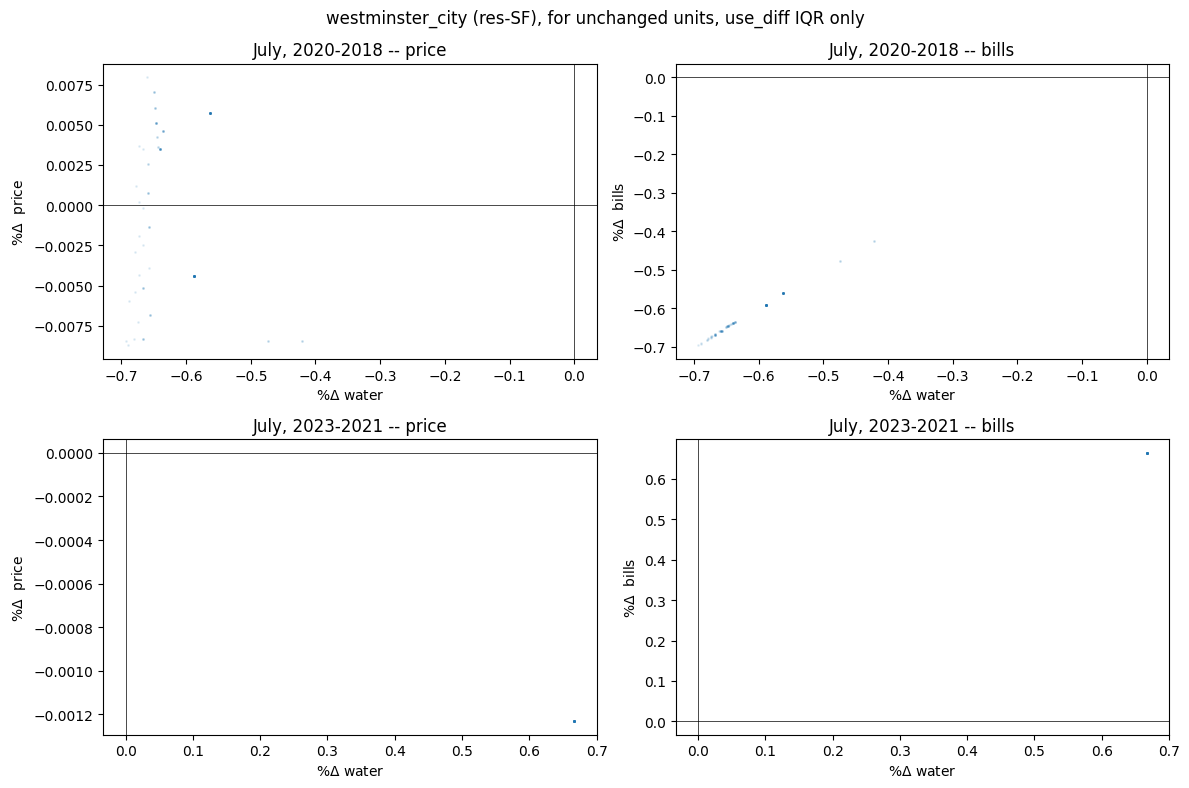

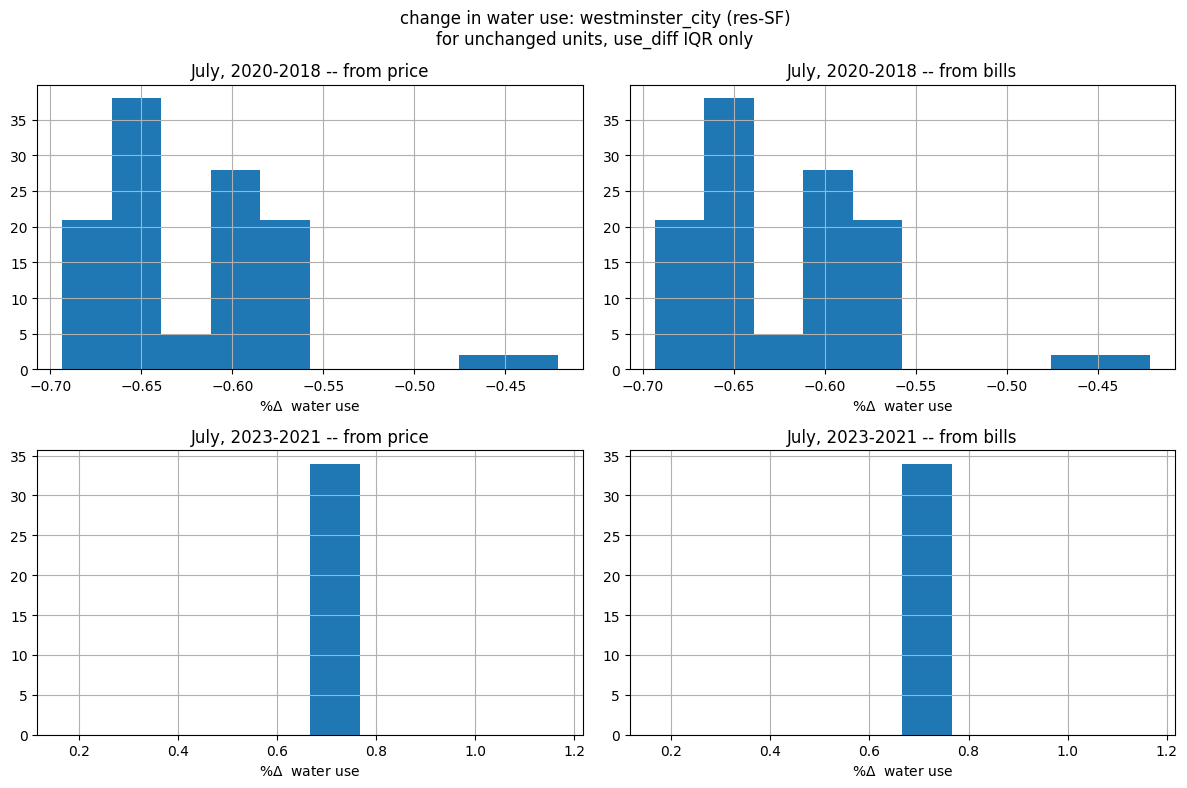

,"July, 2020-2018","July, 2023-2021"
count,117.000000,3.400000e+01
mean,-0.616026,6.666667e-01
std,0.052184,1.126919e-16
min,-0.693548,6.666667e-01
25%,-0.657895,6.666667e-01
50%,-0.640000,6.666667e-01
75%,-0.588235,6.666667e-01
max,-0.421053,6.666667e-01


In [ ]:
sel_month = '07'
fxn_elasticity(data_use=fxn_usage_filter(sel_provider,category=[sel_category]),#,time_endcaps_only=False,year_start=2018,year_end=2020,month=6),
               data_bills=df_bills,
               compare={
                   'y_data': ['price','bills']
                   ,
                   'dates': [{'start':f'2018-{sel_month}-01','end':f'2020-{sel_month}-01'},{'start':f'2021-{sel_month}-01','end':f'2023-{sel_month}-01'}] # westminster
                #    'dates': [{'start':'2014-01-01','end':'2016-01-01'},{'start':'2023-01-01','end':'2025-01-01'}] # foco
               },
               remove_use_diff_outliers=True,
               filter_out_change_in_units=True,
            #    price_diff_bound=0.01,
               show_plots=True,
               investigate=None,
               elas_IQR=True,
               ret_elas_df=False)

In [158]:
print(f'$\\Delta$ ')

$\Delta$ 


> _something something_ calculating the line of 1:1 price per kgal increase to see who may have still used less water, just not enough less so they still show in the top right quadrant??

### testing

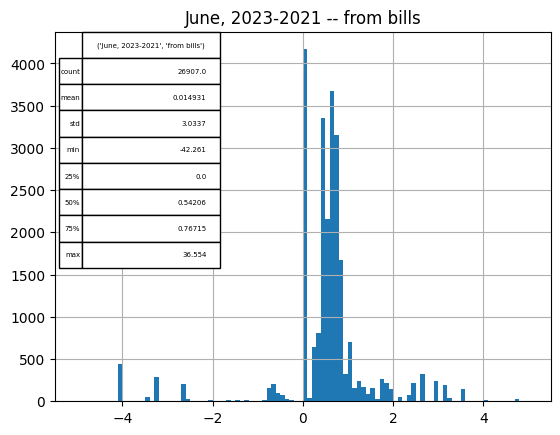

In [ ]:
# new_test_figure = plt.figure()
# subfigs = new_test_figure.subfigures(2,1)
# fig_hist#.add_subplot()

# plt.show()

# subfigs

# fig_hist.add_subfigure(gridspec)

figTest, axTest = plt.subplots()
df_elas.hist(bins=100, range=range_tuple, ax=axTest)#.plot(kind='scatter')        
axTest.set_title(f'{water_x.columns[0]} -- from {y_data}')

axTest2 = figTest.add_subplot(3,3,(1,4),frameon=False)
axTest2.axis('off')
# axTest2.axis('tight')
axTest2.set_xbound(0,1)
axTest2.set_ybound(0,1)
axTest2.table(cellText=df_elas_describe.iloc[:,[3]].map(fxn_round_sigfigs,precision=5),bbox=[0.2,0,1,1],fontsize=30,rowLoc='right')
# df_elas_describe[f'{ax_hist_plot.get_title()}'] = df_elas.describe()
# plt.tight_layout()

In [ ]:
df_elas_describe.to_html(f'utility-data/z_graph_exports/elasticity/{prov}/test')

In [ ]:
price_diff[abs(price_diff)<0.01].dropna()

,"January, 2020-2018"
id,
18496,0.005752
27695,0.005752
30294,0.005752


In [ ]:
df_elas.pipe(fxn_IQR).describe()

,"June, 2020-2018"
count,22700.000000
mean,-0.465358
std,1.222778
min,-4.037628
25%,-1.087838
50%,-0.259676
75%,0.290460
max,3.168577


In [ ]:
print('Maximum elasticity:')
display(water.loc[df_elas.idxmax()])
display(price.loc[df_elas.idxmax()])
print('Minimum elasticity:')
display(water.loc[df_elas.idxmin()])
display(price.loc[df_elas.idxmin()])

Maximum elasticity:


,"June, 2020-2018"
id,
22277,-0.677966


,"June, 2020-2018"
id,
22277,-0.00071


Minimum elasticity:


,"June, 2020-2018"
id,
18976,-0.658537


,"June, 2020-2018"
id,
18976,0.000752


In [ ]:
# df_compare = water.join(price,lsuffix=': water',rsuffix=': price')
# df_ref['n'].loc[df_compare[(df_compare.iloc[:,0] > 0) & (df_compare.iloc[:,1] < 0)].index]

## old

NameError: name 'bills_test' is not defined

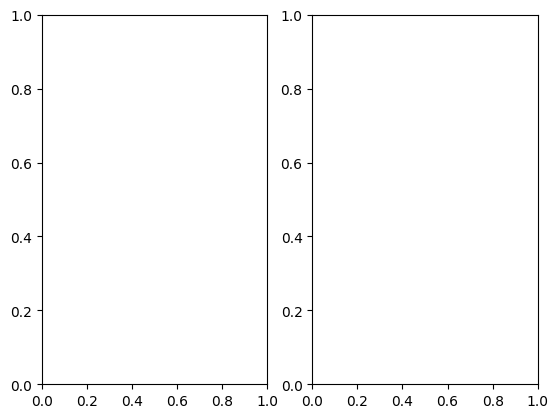

In [82]:
lim = 5

fig_box, ax_box = plt.subplots(1,2)
bills_test.boxplot(ax=ax_box[0])
ax_box[0].set_xlabel('Bill Change (USD $)')
use_test.boxplot(ax=ax_box[1])
ax_box[1].set_xlabel('Usage Change (kgal)')
for i in [0,1]:
    ax_box[i].set_ylim(-lim,lim)
fig_box.suptitle(f'{prov}, {cat}')

In [ ]:
# def fxn_elasticity_old(data_use:pd.DataFrame,data_bills:pd.DataFrame,
#                    filter_out_change_in_units=True,remove_use_diff_outliers=True,
#                    recalculate_bill=False):
        
#         # try:
#         #     df_bills
#         #     df_ref
#         #     df_check
#         # except:
#         #     df_bills = {}
#         #     df_ref = {}
#         #     df_check = {}
#         # else:
#         #     try:
#         #         df_bills[provider]
#         #     except:
#         #         calculate_bill = True
#         #     else:
#         #         calculate_bill = recalculate_bill

#         # if calculate_bill:

#     if data_use.__class__ is tuple:
#         use = data_use[0]
#         units = data_use[1]
#     else:
#         use = data_use
#         filter_out_change_in_units=False

#     if filter_out_change_in_units:
#         units_check = units[units.iloc[:,0]==units.iloc[:,1]]
#         use = use.loc[units_check.index]

#     use_diff = use.pipe(fxn_df_diff,percent_diff=True)

#     if remove_use_diff_outliers:
#         use_diff = use_diff.pipe(fxn_IQR)
#         use = use.loc[use_diff.index]

#     bills = data_bills
#     bills.columns = pd.to_datetime(bills.columns)

#     # to account for weirdness with data export where too many lines were dropped in the overall table, shouldn't need to use this down the line
#     try:
#         bills = bills.loc[use.index,use.columns]
#     except:
#         shared_index = use.index.join(bills.index,how='inner')
#         use = use.loc[shared_index]
#         use_diff = use_diff.loc[shared_index]
#         bills = bills.loc[shared_index,use.columns]

#     bills_diff = bills.pipe(fxn_df_diff,percent_diff=True)
    
#     price = bills / use

#     price_diff = price.pipe(fxn_df_diff,percent_diff=True)

#     return use, use_diff, bills, bills_diff, price, price_diff

# # display(price_diff.head())
# # display(use_diff.head())
# # display(use.shape)
# # price.shape

In [ ]:
df = data_household[sel_provider]
sel_id = 3

In [ ]:
df_usage_yearly = df['usage'].sort_index(axis=1,key=lambda col: col.month + (col.year * 0.0001))
df_usage_yearly.columns.strftime('%b')

Index(['Jan', 'Jan', 'Jan', 'Jan', 'Jan', 'Jan', 'Jan', 'Jan', 'Jan', 'Jan',
       ...
       'Dec', 'Dec', 'Dec', 'Dec', 'Dec', 'Dec', 'Dec', 'Dec', 'Dec', 'Dec'],
      dtype='object', length=120)

In [ ]:
df_usage_yearly.loc[:,(df_usage_yearly.columns.year.isin([2018,2020])) & (df_usage_yearly.columns.month==6)].iloc[:,[1]].columns.month_name()#.head()#.diff(axis=1).iloc[:,[1]].head()

Index(['June'], dtype='object')

In [ ]:
pd.DataFrame([[10,1,5],[None,10,1]]).diff(axis=1)

,0,1,2
0,NaN,-9.0,4
1,NaN,NaN,-9


In [ ]:
df['usage'].diff(axis=1).describe()

,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
count,0.0,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32138.000000,32111.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32364.000000,32362.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32683.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32879.000000,32855.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32971.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33165.000000,33146.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33280.000000,33270.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33424.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33423.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000,33687.000000
mean,NaN,-0.852853,0.190584,1.655486,0.090516,4.156077,8.335148,5.212054,-1.796596,-8.951802,-8.502365,-0.053675,-0.117468,-0.267118,0.515140,-0.039303,1.711037,10.929613,5.063836,2.000309,-4.670436,-7.721450,-5.568687,-1.747405,0.148260,-1.662393,2.491662,0.374139,3.182174,6.007466,9.671419,-6.026803,0.360922,-10.276658,-4.027874,-0.903803,0.734021,-0.288026,-0.118921,0.895678,4.063232,12.208613,3.322394,-4.046261,-1.797317,-8.154293,-6.200097,-0.448554,0.087262,-0.249674,0.088985,0.541370,2.468848,5.823424,5.406694,2.576327,-1.353394,-7.139284,-7.767426,-0.431131,-0.342907,0.592552,0.042816,0.305533,4.020715,9.068476,3.726157,1.249751,-3.506709,-5.806935,-7.185648,-2.155254,-0.306613,-0.249519,0.672626,0.319081,0.416977,5.909375,8.277254,2.093840,-0.679056,-4.438401,-10.058053,-1.407963,-0.265224,0.410543,-0.900042,1.292754,5.506642,6.433521,2.967449,-0.059568,-1.450455,-5.697253,-6.865665,-1.711435,0.067080,-0.041050,-0.383389,0.976842,2.471591,2.652305,3.648476,5.233761,-1.444245,-5.279418,-6.045089,-1.676061,0.350776,-0.274290,-0.459554,0.887316,3.281266,11.494108,5.417164,-1.655683,-1.963755,-5.3494

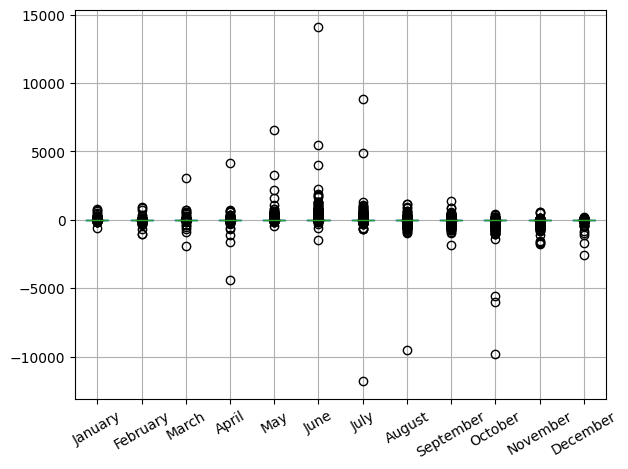

In [ ]:
df['usage'].diff(axis=1)[df['usage'].columns[df['usage'].columns.year==2018]].boxplot()
#.hist(grid=False)
# .iloc[:20]
# plt.gca().set_ylim((-1000,1000))
plt.gca().xaxis.set_ticklabels(month_list[df['usage'].columns[df['usage'].columns.year==2015].month-1],rotation=30)
plt.tight_layout()
plt.show()

### filtering

crazy outliers when looking at just the differences -- like over +/-2000 diff for a given month

--> could these huge values be from multifamily?

--> will need to filter to only look at single family for a better stat description (both boxplot and describe, IQRs are so small otherwise)

In [ ]:
sel_category = 'Residential, Single Family'
code_filter = df['structures'][df['structures']['structure_group']== sel_category]['structure_code'].to_list()
code_filter

['A', 'B', 'P']

In [ ]:
df['structures'][df['structures']['structure_group']== sel_category]

,group_code,structure_group,structure_code,description
0,res-SF,"Residential, Single Family",A,Residential SF Detached
1,res-SF,"Residential, Single Family",B,Residential SF Attached
15,res-SF,"Residential, Single Family",P,Indiv Metered TH


In [ ]:
# df['accounts'].where(df['accounts'].isin(code_filter)).dropna().head()

df['accounts'][df['accounts'].isin(code_filter)].dropna(how='all').head().index

Index([122, 123, 124, 125, 128], dtype='int64', name='id')

In [ ]:
filtered_df = df['usage'].loc[df['accounts'][df['accounts'].isin(code_filter)].dropna(how='all').index]
filtered_df.diff(axis=1).describe()

,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
count,0.0,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29537.000000,29525.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,29962.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30089.000000,30081.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30179.000000,30178.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30316.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30410.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.00000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.000000,30536.00000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000,30603.000000
mean,NaN,-0.413955,0.121068,1.093544,-0.479128,2.114230,4.821444,3.050276,-0.631310,-5.117344,-4.673664,-0.037038,0.030787,-0.352957,0.320157,0.051268,0.696764,6.375698,2.979109,0.756005,-2.604219,-4.192525,-2.693770,-1.476519,0.118179,-0.723383,1.094052,0.454042,1.361825,3.743108,5.372539,-3.824544,0.752954,-6.233496,-1.985348,-0.404646,0.338596,-0.169796,-0.155971,0.626641,2.077171,7.432916,1.603809,-2.731762,-0.813753,-4.584067,-3.402406,-0.146931,0.062465,-0.203022,-0.011796,0.325060,1.399549,2.861592,3.086318,1.817953,-0.834057,-4.222671,-4.088770,-0.260082,-0.025051,0.166007,-0.115255,0.677945,2.724146,4.553522,2.383426,0.359385,-2.264642,-3.231269,-4.030240,-1.075122,-0.099353,-0.222493,0.221638,0.244229,0.170898,3.012693,4.967379,1.495100,-0.622756,-3.121736,-5.176356,-0.605163,-0.285465,-0.069852,-0.410892,1.072996,2.806065,2.966106,2.234510,-0.530194,-0.62631,-3.168784,-3.385610,-1.029768,0.126179,-0.111737,-0.393896,0.635283,1.135676,1.021483,2.314154,2.742304,-0.660008,-2.684340,-3.180476,-1.022695,0.17481,-0.106656,-0.290527,0.536091,1.523184,5.688985,1.820835,-0.641473,-0.987518,-2.402967,-3.8

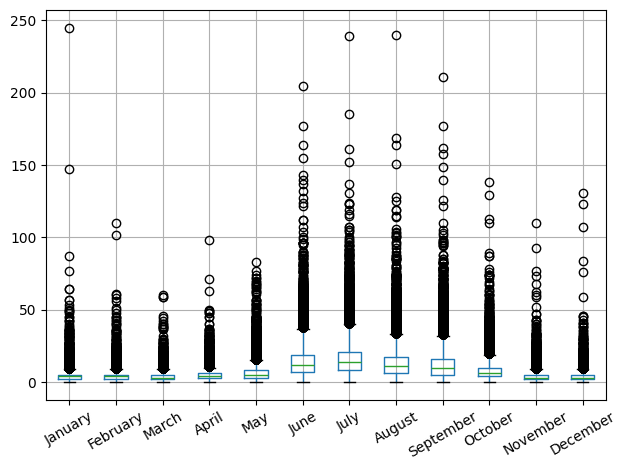

In [ ]:
filtered_df[filtered_df.columns[filtered_df.columns.year==2018]].boxplot() # .month==5
#.hist(grid=False)
# .iloc[:20]
plt.gca().xaxis.set_ticklabels(month_list[filtered_df.columns[filtered_df.columns.year==2018].month-1],rotation=30) # .month==6].year
plt.tight_layout()
plt.show()

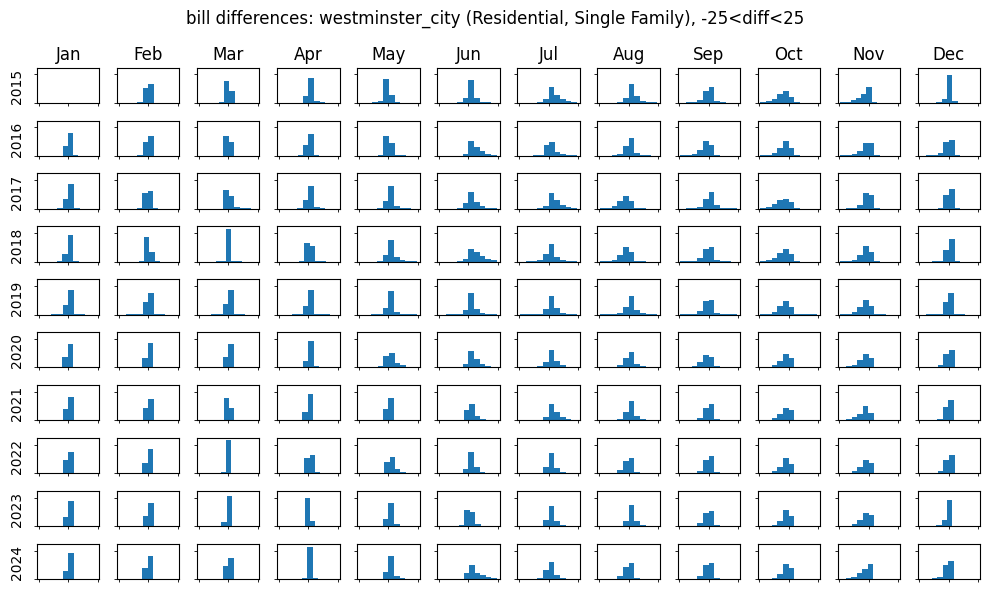

In [ ]:
diff_range = 25 # values on either side of 0 to include for the calculated differences

filtered_df.diff(axis=1)[(filtered_df.diff(axis=1)<diff_range) & (filtered_df.diff(axis=1)>-diff_range)].hist(grid=False,layout=(10,12),sharex=True,figsize=(10,6),sharey=True)#.boxplot()
for i in range(120):
    plt.subplot(10,12,i+1).set_title('')
    plt.subplot(10,12,i+1).set_xticks([])
    plt.subplot(10,12,i+1).set_yticks([])
for i in range(12):
    plt.subplot(10,12,i+1).set_title(month_list[i][:3])
for i in range(10):
    plt.subplot(10,12,1+(i*12)).set_ylabel(2015+i)
# plt.xlabel()
#.hist(grid=False)
# .iloc[:20]
# plt.gca().xaxis.set_ticklabels(filtered_df.columns[filtered_df.columns.month==1].year)    [filtered_df.columns[filtered_df.columns.month==5]]
plt.suptitle(f'bill differences: {sel_provider} ({sel_category}), -{diff_range}<diff<{diff_range}')
plt.tight_layout()
plt.show()

still a fair spread... let's try dividing by the number of units for each
- probably best to divide first and then subtract

In [ ]:
# pd.DatetimeIndex(df['account_units'].columns,yearfirst=True)
df['account_units'].loc[df['accounts'][df['accounts'].isin(code_filter)].dropna(how='all').index].head()
# df['account_units'].head()

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
id,,,,,,,,,,
122,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
123,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
124,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
125,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
128,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [ ]:
filtered_norm_df = filtered_df.apply(lambda x: x / df['account_units'].loc[x.index, x.name.year])
filtered_norm_df.diff(axis=1).iloc[:,1:].describe()#.T.describe()

,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
count,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29535.000000,29525.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.000000,29726.0,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,29961.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30087.000000,30079.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30177.000000,30176.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30323.000000,30315.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30324.000000,30391.0,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30418.00000,30418.000000,30418.000000,30418.000000,30418.000000,30418.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000,30485.000000
mean,-0.410038,0.121656,1.087028,-0.474588,2.103985,4.812494,3.036148,-0.627609,-5.095349,-4.662151,-0.039924,0.026946,-0.345908,0.317873,0.050747,0.694079,6.351652,2.969257,0.756430,-2.595295,-4.172012,-2.687025,-1.477337,inf,-0.716248,1.086798,0.452114,1.358475,3.734805,5.345245,-3.799216,0.747072,-6.214789,-1.977910,-0.402263,0.333694,-0.167370,-0.154992,0.624199,2.075879,7.402194,1.594045,-2.710832,-0.811451,-4.572811,-3.391564,-0.143875,0.058032,-0.198901,-0.010847,0.322206,1.399007,2.849114,3.080540,1.805353,-0.827659,-4.207720,-4.079836,-0.256540,-0.035561,0.162600,-0.118217,0.674008,2.713055,4.529162,2.353710,0.360709,-2.230860,-3.219041,-4.013591,-1.070586,-0.095002,-0.223901,0.220828,0.237489,0.173900,3.000736,4.934971,1.491887,-0.620027,-3.107863,-5.158949,-0.603958,-inf,-0.070490,-0.408717,1.068567,2.810726,2.963306,2.229784,-0.537497,-0.626760,-3.171016,-3.384418,-1.023269,0.126640,-0.111693,-0.392220,0.632244,1.134942,1.016825,2.310186,2.73711,-0.655886,-2.683194,-3.174901,-1.018979,0.173902,-0.106642,-0.286982,0.532741,1.523923,5.672161,1.821035,-0.642354,-0.984841,-2.399581,-3.834515,-1.452606
std,2.608159,1.609659

In [ ]:
filtered_norm_df['2017-01-01'][np.isinf(filtered_norm_df['2017-01-01'])].sort_values()

id
3031    inf
Name: 2017-01-01 00:00:00, dtype: float64

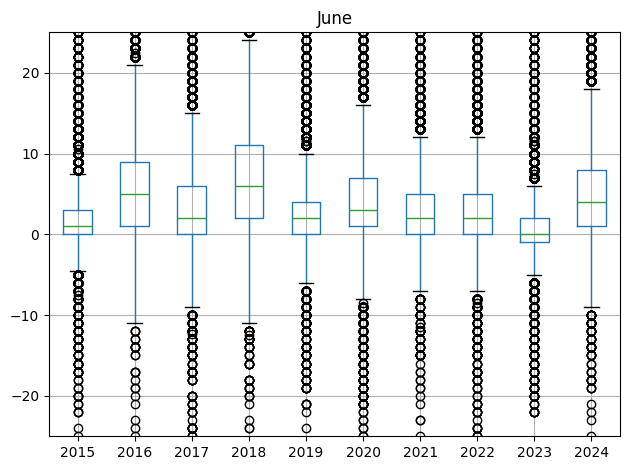

In [ ]:
year_sel = 2020
month_sel = 6
filtered_norm_df.diff(axis=1)[filtered_norm_df.columns[filtered_norm_df.columns.month==month_sel]].boxplot() # .year==year_sel
#.hist(grid=False)
# .iloc[:20]
plt.gca().set_ylim((-25,25))
plt.gca().xaxis.set_ticklabels(filtered_norm_df.columns[filtered_norm_df.columns.month==month_sel].year) # month_list[ ... .year==year_sel].month-1],rotation=30
plt.title('June')
plt.tight_layout()
plt.show()

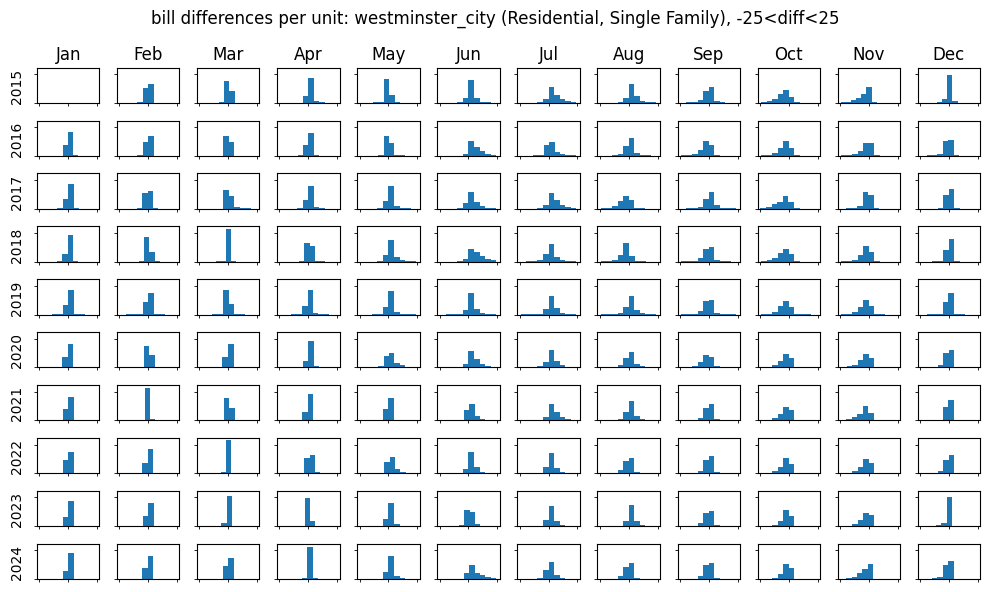

In [ ]:
diff_range = 25 # values on either side of 0 to include for the calculated differences

filtered_norm_df.diff(axis=1)[(filtered_norm_df.diff(axis=1)<diff_range) & (filtered_norm_df.diff(axis=1)>-diff_range)].hist(grid=False,layout=(10,12),sharex=True,figsize=(10,6),sharey=True)#.boxplot()
for i in range(120):
    plt.subplot(10,12,i+1).set_title('')
    plt.subplot(10,12,i+1).set_xticks([])
    plt.subplot(10,12,i+1).set_yticks([])
for i in range(12):
    plt.subplot(10,12,i+1).set_title(month_list[i][:3])
for i in range(10):
    plt.subplot(10,12,1+(i*12)).set_ylabel(2015+i)
# plt.xlabel()
#.hist(grid=False)
# .iloc[:20]
# plt.gca().xaxis.set_ticklabels(filtered_df.columns[filtered_df.columns.month==1].year)    [filtered_df.columns[filtered_df.columns.month==5]]
plt.suptitle(f'bill differences per unit: {sel_provider} ({sel_category}), -{diff_range}<diff<{diff_range}')
plt.tight_layout()
plt.show()

## Statistics :(

- fixed effects regression model
    - look at Nick's paper ($\alpha$ term)

## Are all residential water types potable?

In [ ]:
anls_water_type = metered['residential']['all'].reset_index()[['DNR 1051 Report Name','Water Type','Customer Category']].drop_duplicates().groupby(['Customer Category','Water Type']).count()
# anls_water_type = anls_water_type.rename(columns={'DNR 1051 Report Name':'Qty Reports'})
# anls_water_type['Ratio of Total'] = anls_water_type['Qty Reports'] / anls_water_type['Qty Reports'].sum()

anls_water_type

DNR 1051 Report Name
Customer Category              Water Type                             
Residential, Multi Family                                            4
                               Non-Potable Raw                       2
                               Non-Potable Reuse                     1
                               Potable Treated                     359
Residential, Single Family                                           4
                               Non-Potable Reuse                     1
                               Potable Treated                     371
SF and MF Residential Combined Non-Potable Raw                      21
                               Non-Potable Reuse                     1
                               Potable Treated                     229

No, not all residential water types are potable -- though the vast majority are.

In [ ]:
#_ use this to pull up the list of metered use entries for a given water use type _#

# metered['residential']['all'].loc[(slice(None),slice(None),slice(None),'Non-Potable Reuse')]

In [ ]:
# %who_ls function
%whos function

Variable                   Type        Data/Info
------------------------------------------------
fxn_CPI_load               function    <function fxn_CPI_load at 0x000002264C7416C0>
fxn_IQR                    function    <function fxn_IQR at 0x000002264C7419E0>
fxn_calc_bill              function    <function fxn_calc_bill at 0x0000022606328FE0>
fxn_check_for_plots        function    <function fxn_check_for_p<...>ts at 0x000002264C741620>
fxn_construct_table        function    <function fxn_construct_t<...>le at 0x000002264C7413A0>
fxn_convert_to_gallons     function    <function fxn_convert_to_<...>ns at 0x000002264C741580>
fxn_df_diff                function    <function fxn_df_diff at 0x0000022605AC1E40>
fxn_df_duplicates          function    <function fxn_df_duplicat<...>es at 0x000002264C741440>
fxn_excel_import           function    <function fxn_excel_import at 0x000002261F213CE0>
fxn_gpcd                   function    <function fxn_gpcd at 0x0000022651D0E020>
fxn_pretty_table 